# Full Code Notebook for Vis. 6-12

In [1]:
import os
from pathlib import Path

p = Path("../../monsoonbench/")
os.chdir(p)
print(os.getcwd())
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon
from metrics.climatology import ClimatologyOnsetMetrics
from metrics.probabilistic import ProbabilisticOnsetMetrics
from metrics.deterministic import DeterministicOnsetMetrics
from spatial.regions import get_india_outline

warnings.filterwarnings("ignore")
import xarray as xr
from visualization.plot_config import params

plt.rcParams.update(params)

# config
parent_dir = Path(os.getcwd()).parent.parent / "monsoon-benchmark_data"
print(parent_dir)

/Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-bench/monsoonbench
✓ LaTeX found at: /Library/TeX/texbin/latex
🎨 Scientific plotting configuration loaded
   LaTeX support: ✓ Enabled
   Default save format: png
   Contour levels: 100
   Colormap: bwr
/Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data


In [2]:
parent_dir = Path(os.getcwd()).parent.parent / "monsoon-benchmark_data"
print(parent_dir)

/Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data


In [3]:
# config cell
config = {
    "imd_folder": f"{parent_dir}/imd_rainfall_data/4p0",
    "thresh_file": f"{parent_dir}/imd_onset_threshold/mwset4x4.nc4",
    "india_shpfile": f"{parent_dir}/ind_map_shpfile/india_shapefile.shp"
}

det_model_paths = {
    "AIFS": f"{parent_dir}/rainfall_4p0/AIFS",
    "FuXi": f"{parent_dir}/rainfall_4p0/FuXi",
    "Graphcast": f"{parent_dir}/rainfall_4p0/GraphCast",    
}

prob_model_paths = {
    "FuXi S2S": f"{parent_dir}/rainfall_4p0/FuXi_S2S",
    "NGCM": f"{parent_dir}/rainfall_4p0/NeuralGCM",
    "IFS": f"{parent_dir}/rainfall_4p0/IFS_S2S",
    "GenCast": f"{parent_dir}/rainfall_4p0/GenCast",
}

brier_model_paths = {
    "FuXi S2S": f"{parent_dir}/rainfall_4p0/FuXi_S2S",
    "NGCM": f"{parent_dir}/rainfall_4p0/NeuralGCM",
    "IFS": f"{parent_dir}/rainfall_4p0/IFS_S2S",
}

model_years = {
    "FuXi S2S": [2019, 2020, 2021],
    "IFS": [2019, 2020, 2021, 2022, 2023],
    "Standard": [2019, 2020, 2021, 2022, 2023, 2024]
}

model_dfs_15 = {}
model_onsets_15 = {}
model_dfs_30 = {}
model_onsets_30 = {}

thresh_slice = xr.open_dataset(config["thresh_file"])["MWmean"]


## Loading Climatology Data

In [4]:
# Get climatology metrics

climatology = ClimatologyOnsetMetrics()

metrics_df_clim_15, onset_da_clim_15 = climatology.compute_climatology_baseline_multiple_years(
    years=model_years["Standard"],
    imd_folder=config["imd_folder"],
    thres_file=config["thresh_file"],
    tolerance_days=3,
    verification_window=1,
    forecast_days=15,
    max_forecast_day=15,
    mok=True,
    onset_window=5,
    mok_month=6,
    mok_day=2,
)

metrics_df_clim_30, onset_da_clim_30 = climatology.compute_climatology_baseline_multiple_years(
    years=model_years["Standard"],
    imd_folder=config["imd_folder"],
    thres_file=config["thresh_file"],
    tolerance_days=5,
    verification_window=16,
    forecast_days=30,
    max_forecast_day=30,
    mok=True,
    onset_window=5,
    mok_month=6,
    mok_day=2,
)

spatial_clim_15_day = climatology.create_spatial_far_mr_mae(
    metrics_df_clim_15,
    dict.fromkeys(model_years["Standard"], onset_da_clim_15)
)

spatial_clim_30_day = climatology.create_spatial_far_mr_mae(
    metrics_df_clim_30,
    dict.fromkeys(model_years["Standard"], onset_da_clim_30)
)

Computing climatological onset reference...
Computing climatological onset from 124 years: 1901-2024
Loading IMD rainfall from: /Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_rainfall_data/4p0/1901.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
Loading IMD rainfall from: /Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_rainfall_data/4p0/1902.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1902-06-02) as start date for onset detection
Loading IMD rainfall from: /Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_rainfall_data/4p0/1903.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1903-06-02) as start date for onset detection
Loading IMD rainfall from: /Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_rainfall_data/4p0/1904.nc
Renamed dimensions: {'TIME': 'time'}
Using MO

## Loading Data for Spatial Metrics

In [5]:
p_metrics = ProbabilisticOnsetMetrics()
d_metrics = DeterministicOnsetMetrics()

for model_name, model_fp in prob_model_paths.items():
    print("="*80)
    print(f"Loading data from {model_name}")
    print("="*80)
    probabilistic_df_15, onset_da_dict_15 = p_metrics.compute_metrics_multiple_years(
            years=(
                model_years[model_name] if model_name in model_years.keys() else model_years["Standard"]
                ),
            imd_folder=config["imd_folder"],
            thres_file=config["thresh_file"],
            model_forecast_dir=model_fp,
            tolerance_days=3,
            verification_window=1,
            forecast_days=15,
            max_forecast_day=15,
            mok=True,
            onset_window=5,
            mok_month=6,
            mok_day=2,
        )
    
    probabilistic_df_30, onset_da_dict_30 = p_metrics.compute_metrics_multiple_years(
            years=(
                model_years[model_name] if model_name in model_years.keys() else model_years["Standard"]
                ),
            imd_folder=config["imd_folder"],
            thres_file=config["thresh_file"],
            model_forecast_dir=model_fp,
            tolerance_days=5,
            verification_window=16,
            forecast_days=30,
            max_forecast_day=30,
            mok=True,
            onset_window=5,
            mok_month=6,
            mok_day=2,
        )

    model_dfs_15[model_name] = probabilistic_df_15
    model_onsets_15[model_name] = onset_da_dict_15
    model_dfs_30[model_name] = probabilistic_df_30
    model_onsets_30[model_name] = onset_da_dict_30


for model_name, model_fp in det_model_paths.items():
    print("="*80)
    print(f"Loading data from {model_name}")
    print("="*80)
    deterministic_df_15, onset_da_dict_15 = d_metrics.compute_metrics_multiple_years(
            years=(
                model_years[model_name] if model_name in model_years.keys() else model_years["Standard"]
                ),
            imd_folder=config["imd_folder"],
            thres_file=config["thresh_file"],
            model_forecast_dir=model_fp,
            tolerance_days=3,
            verification_window=1,
            forecast_days=15,
            max_forecast_day=15,
            mok=True,
            onset_window=5,
            mok_month=6,
            mok_day=2,
        )
    
    deterministic_df_30, onset_da_dict_30 = d_metrics.compute_metrics_multiple_years(
            years=(
                model_years[model_name] if model_name in model_years.keys() else model_years["Standard"]
                ),
            imd_folder=config["imd_folder"],
            thres_file=config["thresh_file"],
            model_forecast_dir=model_fp,
            tolerance_days=5,
            verification_window=16,
            forecast_days=30,
            max_forecast_day=30,
            mok=True,
            onset_window=5,
            mok_month=6,
            mok_day=2,
        )

    model_dfs_15[model_name] = deterministic_df_15
    model_onsets_15[model_name] = onset_da_dict_15
    model_dfs_30[model_name] = deterministic_df_30
    model_onsets_30[model_name] = onset_da_dict_30

Loading data from FuXi S2S

Processing year 2019
Loading IMD rainfall from: /Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_rainfall_data/4p0/2019.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Processing 13 init times x 8 lats x 9 lons...
Using MOK (6/2 filter) for onset detection
Only processing forecasts initialized before observed onset dates
Requiring ≥50% of 51 members to have onset for ensemble onset
Processing init time 1/13: 2019-05-02
Processing init time 6/13: 2019-06-06
Processing init time 11/13: 2019-07-11

Processing Summary:
Total potential initializations: 936
Skipped (no observed onset): 481
Skipped (initialized after observed onset): 186
Valid initializations processed: 269
Ensemble onsets found (≥50% members): 75
Ensemble onset rate: 0.279
Note: Only onsets on or after 6/2 were counted due to MOK flag
Computing onset metrics with tolerance = 3 days
Verification window sta

## Loading Data for Probabalisitc Metrics

__Brier and RPS__

In [6]:
forecast_dfs_15 = {}
forecast_dfs_30 = {}
for model_name, model_fp in brier_model_paths.items():
    print("="*80)
    print(f"Loading data from {model_name}")
    print("="*80)
    multi_year_df = p_metrics.multi_year_forecast_obs_pairs(
            range(2004, 2022),
            model_forecast_dir=model_fp,
            imd_folder=config["imd_folder"],
            thres_file=config["thresh_file"],
            mem_num=51 if model_name != "IFS" else 11,
            max_forecast_day=15,
            day_bins=[(1, 5), (6, 10), (11, 15)],
            cmz_only=False,
            date_filter_year=2024 if model_name != "IFS" else 2022
        )
    forecast_dfs_15[model_name] = multi_year_df

    multi_year_df = p_metrics.multi_year_forecast_obs_pairs(
            range(2004, 2022),
            model_forecast_dir=model_fp,
            imd_folder=config["imd_folder"],
            thres_file=config["thresh_file"],
            mem_num=51 if model_name != "IFS" else 11,
            max_forecast_day=30,
            day_bins=[(1, 10), (11, 20), (21, 30)],
            cmz_only=False,
            date_filter_year=2024 if model_name != "IFS" else 2022
        )
    forecast_dfs_30[model_name] = multi_year_df
  

Loading data from FuXi S2S
Processing years: range(2004, 2022)
All-domain mode: using 8 lat x 9 lon grid points

Processing year 2004
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_rainfall_data/4p0/2004.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2004-06-02) as start date for onset detection
Found onset in 36 out of 72 grid points
Computing onset for all ensemble members...
Processing 13 init times x 8 unique locations x 51 members...
Unique lat-lon pairs: [(np.float64(68.0), np.float64(8.0)), (np.float64(72.0), np.float64(12.0)), (np.float64(76.0), np.float64(16.0)), (np.float64(80.0), np.float64(20.0)), (np.float64(84.0), np.float64(24.0)), (np.float64(88.0), np.float64(28.0)), (np.float64(92.0), np.float64(32.0)), (np.float64(96.0), np.float64(36.0))]
Using MOK (June 2nd filter) for onset detection
Processing init time 1

## Formatting Data for Plots

In [46]:
def reorder_dict(
        dict,
        order=[
            "Climatology",
            "IFS",
            "AIFS",
            "FuXi",
            "Graphcast",
            "GenCast",
            "FuXi S2S",
            "NGCM"
        ]
        ):
    reordered_dict = {key: dict[key] for key in order}
    return reordered_dict

prob_plot_data_15 = {}
prob_plot_data_30 = {}

for model_name in prob_model_paths.keys():
    probabilistic_df = model_dfs_15[model_name]
    onset_da_dict = model_onsets_15[model_name]
    plot_probabilistic_metrics = p_metrics.create_spatial_far_mr_mae(
        probabilistic_df, onset_da_dict
    )
    plot_probabilistic_metrics["false_alarm_rate"] = plot_probabilistic_metrics["false_alarm_rate"].round(3)*100
    plot_probabilistic_metrics["miss_rate"] = plot_probabilistic_metrics["miss_rate"].round(3)*100
    prob_plot_data_15[model_name] = plot_probabilistic_metrics

for model_name in prob_model_paths.keys():
    probabilistic_df = model_dfs_30[model_name]
    onset_da_dict = model_onsets_30[model_name]
    plot_probabilistic_metrics = p_metrics.create_spatial_far_mr_mae(
        probabilistic_df, onset_da_dict
    )
    plot_probabilistic_metrics["false_alarm_rate"] = plot_probabilistic_metrics["false_alarm_rate"].round(3)*100
    plot_probabilistic_metrics["miss_rate"] = plot_probabilistic_metrics["miss_rate"].round(3)*100
    prob_plot_data_30[model_name] = plot_probabilistic_metrics

for model_name in det_model_paths.keys():
    deterministic_df = model_dfs_15[model_name]
    onset_da_dict = model_onsets_15[model_name]
    plot_deterministic_metrics = d_metrics.create_spatial_far_mr_mae(
        deterministic_df, onset_da_dict
    )
    plot_deterministic_metrics["false_alarm_rate"] = plot_deterministic_metrics["false_alarm_rate"].round(3)*100
    plot_deterministic_metrics["miss_rate"] = plot_deterministic_metrics["miss_rate"].round(3)*100

    prob_plot_data_15[model_name] = plot_deterministic_metrics

for model_name in det_model_paths.keys():
    deterministic_df = model_dfs_30[model_name]
    onset_da_dict = model_onsets_30[model_name]
    plot_deterministic_metrics = d_metrics.create_spatial_far_mr_mae(
        deterministic_df, onset_da_dict
    )
    plot_deterministic_metrics["false_alarm_rate"] = plot_deterministic_metrics["false_alarm_rate"].round(3)*100
    plot_deterministic_metrics["miss_rate"] = plot_deterministic_metrics["miss_rate"].round(3)*100
    prob_plot_data_30[model_name] = plot_deterministic_metrics

clim_plot_data_15 = climatology.create_spatial_far_mr_mae(
    metrics_df_clim_15, dict.fromkeys(model_years["Standard"], onset_da_clim_15)
)
clim_plot_data_15["false_alarm_rate"] = clim_plot_data_15["false_alarm_rate"].round(3) * 100
clim_plot_data_15["miss_rate"] = clim_plot_data_15["miss_rate"].round(3) * 100


clim_plot_data_30 = climatology.create_spatial_far_mr_mae(
    metrics_df_clim_30, dict.fromkeys(model_years["Standard"], onset_da_clim_30)
)
clim_plot_data_30["false_alarm_rate"] = clim_plot_data_30["false_alarm_rate"].round(3) * 100
clim_plot_data_30["miss_rate"] = clim_plot_data_30["miss_rate"].round(3) * 100

prob_plot_data_15["Climatology"] = clim_plot_data_15
prob_plot_data_30["Climatology"] = clim_plot_data_30

prob_plot_data_15 = reorder_dict(prob_plot_data_15)
prob_plot_data_30 = reorder_dict(prob_plot_data_30)

Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...
Grid dimensions: 8 lats x 9 lons
Years: [2019, 2020, 2021]


Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...
Grid dimensions: 8 lats x 9 lons
Years: [2019, 2020, 2021, 2022, 2023, 2024]
Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...
Grid dimensions: 8 lats x 9 lons
Years: [2019, 2020, 2021, 2022, 2023]
Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...
Grid dimensions: 8 lats x 9 lons
Years: [2019, 2020, 2021, 2022, 2023, 2024]
Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...
Grid dimensions: 8 lats x 9 lons
Years: [2019, 2020, 2021]
Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...
Grid dimensions: 8 lats x 9 lons
Years: [2019, 2020, 2021, 2022, 2023, 2024]
Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...
Grid dimensions: 8 lats x 9 lons
Years: [2019, 2020, 2021, 2022, 2023]
Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...
Grid dimensions: 8 lats x 9 lons
Years: [2019, 2020, 2021, 2022, 2023, 2024]
Creating spatial FAR, Miss Ra

In [9]:
# Functions for getting gridwise RPS and Brier
def calculate_gridwise_brier(forecast_obs_df):
    """Calculate Brier Score and Fair Brier Score for each grid point (lat, lon).
    
    Parameters:
    -----------
    forecast_obs_df : DataFrame
        Output from create_forecast_observation_pairs_with_bins()
        Must contain columns: 'lat', 'lon', 'predicted_prob', 'observed_onset', 'total_members'
    
    Returns:
    --------
    xarray.DataArray with dimensions (lat, lon) containing gridwise Brier scores
    """
    results_list = []
    unique_locs = forecast_obs_df[["lat", "lon"]].drop_duplicates()
    for idx, row in unique_locs.iterrows():
        lat = row["lat"]
        lon = row["lon"]
        
        # Filter data for this grid point
        grid_data = forecast_obs_df[(forecast_obs_df["lat"] == lat) & 
                                     (forecast_obs_df["lon"] == lon)]
        

        loop_res = p_metrics.calculate_brier_score(grid_data)

        loop_dict = {
            "lat": lat,
            "lon": lon,
            "brier_score": loop_res["brier_score"],
            "fair_brier_score": loop_res["fair_brier_score"]
        }
        results_list.append(loop_dict)

    results_df = pd.DataFrame(results_list).set_index(
        ["lat", "lon"]
    )
    results_ds = results_df.to_xarray()
    
    return results_ds


def calculate_gridwise_rps(forecast_obs_df):
    """Calculate RPS and Fair RPS for each grid point (lat, lon).
    
    Parameters:
    -----------
    forecast_obs_df : DataFrame
        Output from create_forecast_observation_pairs_with_bins()
        Must contain columns: 'lat', 'lon', 'predicted_prob', 'observed_onset', 'total_members'
    
    Returns:
    --------
    xarray.DataArray with dimensions (lat, lon) containing gridwise RPS scores
    """
    results_list = []
    unique_locs = forecast_obs_df[["lat", "lon"]].drop_duplicates()
    for idx, row in unique_locs.iterrows():
        lat = row["lat"]
        lon = row["lon"]
        
        # Filter data for this grid point
        grid_data = forecast_obs_df[(forecast_obs_df["lat"] == lat) & 
                                     (forecast_obs_df["lon"] == lon)]
        

        loop_res = p_metrics.calculate_rps(grid_data)

        loop_dict = {
            "lat": lat,
            "lon": lon,
            "rps": loop_res["rps"],
            "fair_rps": loop_res["fair_rps"]
        }
        results_list.append(loop_dict)

    results_df = pd.DataFrame(results_list).set_index(
        ["lat", "lon"]
    )
    results_ds = results_df.to_xarray()
    
    return results_ds

In [70]:
brier_15_ds = {}
brier_30_ds = {}
rps_15_ds = {}
rps_30_ds = {}

for model, df in forecast_dfs_15.items():
    loop_grid_brier = calculate_gridwise_brier(df)
    brier_15_ds[model] = loop_grid_brier

for model, df in forecast_dfs_30.items():
    loop_grid_brier = calculate_gridwise_brier(df)
    brier_30_ds[model] = loop_grid_brier

for model, df in forecast_dfs_15.items():
    loop_grid_rps = calculate_gridwise_rps(df)
    rps_15_ds[model] = loop_grid_rps


for model, df in forecast_dfs_30.items():
    loop_grid_rps = calculate_gridwise_rps(df)
    rps_30_ds[model] = loop_grid_rps

brier_rps_graph_data_list = [
    brier_15_ds,
    brier_30_ds,
    rps_15_ds,
    rps_30_ds
]

Brier Score: 0.0753
Fair Brier Score: 0.0751
Brier Score: 0.1042
Fair Brier Score: 0.1037
Brier Score: 0.0690
Fair Brier Score: 0.0688
Brier Score: 0.1082
Fair Brier Score: 0.1078
Brier Score: 0.1060
Fair Brier Score: 0.1056
Brier Score: 0.0513
Fair Brier Score: 0.0509
Brier Score: 0.0889
Fair Brier Score: 0.0883
Brier Score: 0.0925
Fair Brier Score: 0.0922
Brier Score: 0.1399
Fair Brier Score: 0.1395
Brier Score: 0.0963
Fair Brier Score: 0.0958
Brier Score: 0.0896
Fair Brier Score: 0.0890
Brier Score: 0.0887
Fair Brier Score: 0.0882
Brier Score: 0.0868
Fair Brier Score: 0.0863
Brier Score: 0.1390
Fair Brier Score: 0.1387
Brier Score: 0.0880
Fair Brier Score: 0.0877
Brier Score: 0.0753
Fair Brier Score: 0.0749
Brier Score: 0.0627
Fair Brier Score: 0.0622
Brier Score: 0.0713
Fair Brier Score: 0.0707
Brier Score: 0.0857
Fair Brier Score: 0.0853
Brier Score: 0.1024
Fair Brier Score: 0.1019
Brier Score: 0.0940
Fair Brier Score: 0.0937
Brier Score: 0.1505
Fair Brier Score: 0.1503
Brier Scor

## Plotting

In [40]:
# Defining Variables
models = list(prob_model_paths.keys()) + list(det_model_paths.keys())
metrics = [
    "mean_mae",
    "false_alarm_rate",
    "miss_rate",
]
horizons = [15, 30]  # 15-day and 30-day horizons

model_labels = {}
for i in models:
    model_labels[i] = i

# Plot configuration
SMALL_SIZE = 6
MEDIUM_SIZE = 7
LARGE_SIZE = 8

# Define Core Monsoon Zone polygon (same as reference)
polygon1_lon = np.array([86, 74, 74, 70, 70, 82, 82, 86, 86])
polygon1_lat = np.array([18, 18, 22, 22, 30, 30, 26, 26, 18])

panel_linewidth = 0.5
map_lw = 0.5
polygon_lw = 1.3
tick_length = 2
tick_width = 0.5

brier_levels = np.arange(0,0.2,0.02)
rps_levels = np.arange(0,0.5,0.05)

color_bar_map = {
    "mean_mae": """MAE (days)""",
    "false_alarm_rate": """False alarm rate (%)""",
    "miss_rate": """Miss rate (%)""",
}


In [ ]:
# Defining Plot Functions
def cmz_text_formatter(val:float,
                       metric:str):
    if "mae" in metric:
        metric_text = f"MAE: {val:.1f}"
    elif metric == "false_alarm_rate":
        metric_text = f"FAR: {val:.1f}" 
    elif metric == "miss_rate":
        metric_text = f"MR: {val:.1f}"
    elif "brier" in metric:
        metric_text = f"Brier: {val:.1f}"
    elif "rps" in metric:
        metric_text = f"RPS: {val:.1f}"
    return metric_text

def create_discrete_colormap(levels, base_cmap="RdBu"):
    """Create a discrete colormap with specified levels"""
    cmap = plt.cm.get_cmap(base_cmap)
    norm = colors.BoundaryNorm(levels, cmap.N, clip=True)
    return cmap, norm


def create_map_instance_for_model(ax, data_array, model,
                              metric:str,
                              vmin=-100, vmax=100, show_ylabel=True,
                              show_xlabel=True,
                              title=None,
                              levels=None,
                              cmap="YlOrRd"
                              ):
    """Create a skill map panel using xarray DataArray with India boundaries
    """
    if data_array.isnull().all():
        ax.text(0.5, 0.5, f"No data for {model}", 
                transform=ax.transAxes, ha="center", va="center")
        return None
    
    # Get coordinates
    lats = data_array.lat.values
    lons = data_array.lon.values
    
    # Create edges for pcolormesh
    lat_edges = np.concatenate([lats - 2, [lats[-1] + 2]])
    lon_edges = np.concatenate([lons - 2, [lons[-1] + 2]])

    # Create discrete colormap and normalization
    if levels is not None:
        cmap, norm = create_discrete_colormap(levels, cmap)
        vmin, vmax = None, None  # Let norm handle the range
    else:
        cmap = cmap
        norm = None
        vmin, vmax = vmin, vmax
    
    # Create pcolormesh plot
    im = ax.pcolormesh(lon_edges, lat_edges, data_array.values,
                      transform=ccrs.PlateCarree(),
                      cmap=cmap, norm=norm, vmin=vmin, vmax=vmax, shading="flat")

    # Add India boundaries using the get_india_outline function
    try:
        india_boundaries = get_india_outline(
            shp_file_path=config["india_shpfile"]
        )
        for boundary in india_boundaries:
            india_lon, india_lat = boundary
            ax.plot(india_lon, india_lat, color="black", linewidth=map_lw, 
                   transform=ccrs.PlateCarree())
    except Exception as e:
        print(f"Warning: Could not load India boundaries: {e}")
        # Fallback to coastlines if India outline fails
        ax.add_feature(cfeature.COASTLINE, linewidth=map_lw, color="black")
    
    # Add Core Monsoon Zone polygon
    polygon = Polygon(list(zip(polygon1_lon, polygon1_lat)), 
                     fill=False, edgecolor="black", linewidth=polygon_lw,
                     transform=ccrs.PlateCarree())
    ax.add_patch(polygon)
    
    # Calculate average value inside the polygon
    from matplotlib.path import Path
    polygon_path = Path(list(zip(polygon1_lon, polygon1_lat)))
    
    # Find grid points inside the polygon
    values_in_polygon = []
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            if polygon_path.contains_point((lon, lat)):
                value = data_array.values[i, j]
                if not np.isnan(value):
                    values_in_polygon.append(value)
    
    
    # Calculate and display average
    if values_in_polygon:
        avg_value = np.mean(values_in_polygon)
        cmz_text = cmz_text_formatter(val=avg_value,
                                      metric=metric)
        # Add average value text in bottom-right corner
        ax.text(0.95, 0.05, cmz_text, 
                transform=ax.transAxes,
                horizontalalignment="right", verticalalignment="bottom",
                color="black", fontsize=MEDIUM_SIZE, fontweight="normal")
    
    # Add model name text in top-right using the mapped label
    model_label = model_labels.get(model, model.upper())
    ax.text(0.95, 0.95, model_label, transform=ax.transAxes,
            horizontalalignment="right", verticalalignment="top",
            color="black", fontsize=MEDIUM_SIZE, fontweight="normal")
    
 
    # Set axis limits and ticks
    ax.set_xlim([lons[0]-4, 100])
    ax.set_ylim([lats[0]-4, lats[-1]+4])
    
    # Create tick labels
    yticks = np.arange(lats[0]-2, lats[-1]+3, 8)
    yticklabels = [f"{int(y)}°N" if i % 1 == 0 else "" for i, y in enumerate(yticks)]
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    if show_ylabel:
        ax.set_yticklabels(yticklabels)
    else:
        ax.set_yticklabels([])
    
    xticks = np.arange(lons[0]-2, lons[-1]+3, 8)
    xticklabels = [f"{int(x)}°E" if i % 1 == 0 else "" for i, x in enumerate(xticks)]
    ax.set_xticks(xticks)
    if show_xlabel:
        ax.set_xticklabels(xticklabels)
    else:
        ax.set_xticklabels([])
    
    # Styling
    ax.tick_params(axis="both", which="major", labelsize=SMALL_SIZE, 
                  length=tick_length, width=tick_width)
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_linewidth(panel_linewidth)
    
    # Remove grid lines
    ax.grid(False)
    ax.set_axisbelow(False)
    ax.tick_params(axis="x", which="minor", bottom=False, top=False)
    ax.tick_params(axis="y", which="minor", left=False, right=False)
    
    if title:
        ax.text(0.02, 1.02, title, transform=ax.transAxes, 
                verticalalignment="bottom", fontsize=LARGE_SIZE, fontweight="normal")
    
    return im, levels

# Create grid of map instances function
def create_spatial_metric_figure_xr(plot_data: dict[str,xr.Dataset],
                              metric:str,
                              vmin:float=None,
                              vmax:float=None,
                              figure_title:str=None,
                              cmap="YlOrRd",
                              n_colors:int=10):
    """Create the complete figure using xarray DataArrays"""
    plot_data_arrays = {
        model: data[metric]
        for model, data in plot_data.items()
        }

    # Dynamic Scaling
    all_values = np.concatenate([
        da.values.flatten()
        for da in plot_data_arrays.values()
    ])

    if vmin is None:
        vmin = np.nanmin(all_values)

    if vmax is None:
        vmax = np.nanmax(all_values)

    levels = np.linspace(vmin, vmax, n_colors + 1)

    n_models = len(plot_data_arrays)
    n_cols = 2
    n_rows = int(np.ceil(n_models / n_cols))

    
    # # Create the main figure
    fig = plt.figure(figsize=(6, 9),
                     dpi=300)

    # Create GridSpec for better control - 4 rows, 10 columns
    gs = GridSpec(
    n_rows,
    n_cols + 1,
    figure=fig,
    hspace=0.05,
    wspace=-0.2,
    left=0.05,
    right=0.85,
    top=0.95,
    bottom=0.05,
    width_ratios=[1, 1, 0.08]
)

    
    axes = np.empty((n_rows, n_cols), dtype=object)

    for r in range(n_rows):
        for c in range(n_cols):
            axes[r, c] = fig.add_subplot(
                gs[r, c],
                projection=ccrs.PlateCarree()
            )

    im_for_colorbar = None
    levels_for_colorbar = None

    for i, (model, model_data) in enumerate(plot_data_arrays.items()):
        r, c = divmod(i, n_cols)
            
        # Create the map instance
        show_ylabel = (c == 0)
        show_xlabel = (r == n_rows - 1)

        result = create_map_instance_for_model(
            axes[r, c],
            model_data,
            model,
            metric=metric,
            vmin=vmin,
            vmax=vmax,
            show_ylabel=show_ylabel,
            show_xlabel=show_xlabel,
            cmap=cmap,
            levels=levels
        )

        axes[r, c].set_aspect("equal", adjustable="box")
        
        if result is not None and im_for_colorbar is None:
            im_for_colorbar, levels_for_colorbar = result


    for idx in range(n_models, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r, c].axis("off")

    if im_for_colorbar is not None:

        # Get positions of ALL active axes
        active_axes = [
            axes[r, c]
            for r in range(n_rows)
            for c in range(n_cols)
            if axes[r, c].axison
        ]

        positions = [ax.get_position() for ax in active_axes]

        # Find vertical span of panel grid
        top = max(p.y1 for p in positions)
        bottom = min(p.y0 for p in positions)

        single_panel_height = positions[0].y1 - positions[0].y0
        two_panel_height = single_panel_height * 2

        # Center within full grid span
        grid_center = (top + bottom) / 2
        cbar_y = grid_center - two_panel_height / 2

        cax = fig.add_axes([
            0.87,
            cbar_y,
            0.025,
            two_panel_height
        ])

        cbar = fig.colorbar(
            im_for_colorbar,
            cax=cax,
            orientation="vertical",
            extend=None if metric == "miss_rate" else "max",
            spacing="uniform",
            boundaries=levels_for_colorbar,
            ticks=levels_for_colorbar
        )

        cbar.set_label(color_bar_map[metric], usetex=False)
        cbar.set_ticks(np.arange(vmin, vmax+1, (vmin+vmax)/5))
        cbar.ax.minorticks_off()
        cbar.ax.tick_params(length=2, width=1)


    if figure_title:
        fig.suptitle(figure_title)

    return fig


def create_brier_rps_maps_figure_from_datasets(
    datasets_list: list[dict],
):
    """Create multi-row skill maps figure using create_brier_rps_side_by_side framework
    
    Parameters:
    -----------
    datasets_list : list of dict
        List of dictionaries, one per row: [{model: dataset, model: dataset}, {...}, ...]
        Example: [
            {'GenCast': gencast_brier_15, 'FUXI': fuxi_brier_15, 'GraphCast': gc_brier_15},
            {'GenCast': gencast_brier_30, 'FUXI': fuxi_brier_30, 'GraphCast': gc_brier_30},
            {'GenCast': gencast_rps_15, 'FUXI': fuxi_rps_15, 'GraphCast': gc_rps_15},
            {'GenCast': gencast_rps_30, 'FUXI': fuxi_rps_30, 'GraphCast': gc_rps_30}
        ]
    figsize : tuple
        Figure size (width, height)
    save_prefix : str
        Prefix for saved files (e.g., 'fig6' -> 'fig6.png', 'fig6.pdf')
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
    data_arrays : list of lists
        The data arrays used in each row
    """
    titles = {
        0: "(a) Brier Skill Score: 15-day forecast",
        1: "(b) Brier Skill Score: 30-day forecast", 
        2: "(c) Ranked Probability Skill Score: 15-day forecast",
        3: "(d) Ranked Probability Skill Score: 30-day forecast"
    }
    
    row_configs = [
        ("brier_score", 15),
        ("brier_score", 30),
        ("rps", 15),
        ("rps", 30)
    ]
    
    
    n_rows = len(datasets_list)
    n_models = len(list(datasets_list[0].keys()))
    n_cols = n_models + 1
    # Create the main figure
    fig = plt.figure(figsize=(6, 4 * n_rows / 2), dpi=300)
    
    # Width ratios: equal for maps, small for colorbar
    width_ratios = [1] * n_models + [0.02]
    
    # Create GridSpec
    gs = GridSpec(
        n_rows, n_cols,
        figure=fig,
        hspace=0.15,
        wspace=0.3,
        left=0.05,
        right=0.85,
        top=0.95,
        bottom=0.05,
        width_ratios=width_ratios
    )
    
    # Storage for axes and data
    axes = []
    data_arrays = []
    colorbars_data = []
    
    # Process each row
    for row_idx, (metric, horizon) in enumerate(row_configs):
        row_axes = []
        row_data = []
        
        # Choose levels based on metric
        if "brier" in metric:
            levels = brier_levels
        else:  # RPS
            levels = rps_levels
        
        # Get the data dictionary for this row
        plot_data = datasets_list[row_idx]
        
        # Create axes for this row and plot
        im = None
        for model_idx, (model, data_array) in enumerate(plot_data.items()):
            # Create axis
            ax = fig.add_subplot(gs[row_idx, model_idx], 
                               projection=ccrs.PlateCarree())
            row_axes.append(ax)
            row_data.append(data_array)
            
            # Determine labels
            show_ylabel = (model_idx == 0)
            show_xlabel = (row_idx == n_rows - 1)
            
            # Add row title to first panel only
            title = titles.get(row_idx) if (titles and model_idx == 0) else None
            # Create the map with discrete levels
            result = create_map_instance_for_model(
                ax, data_array[metric], model, metric,
                vmin=None,
                vmax=None,
                show_ylabel=show_ylabel,
                show_xlabel=show_xlabel,
                cmap="RdBu",
                levels=levels,
                title=title
            )
            
            # Store colorbar data from first model in each row
            if model_idx == 0 and result is not None:
                if isinstance(result, tuple):
                    im, used_levels = result
                else:
                    im = result
                    used_levels = levels
                colorbars_data.append((row_idx, im, metric, used_levels))
            
            # ax.set_aspect('equal', adjustable='box')
        
        axes.append(row_axes)
        data_arrays.append(row_data)
    
    if len(colorbars_data) >= 2:
        brier_data = [item for item in colorbars_data if "brier" in item[2]]
        if brier_data:
            _, im, _, levels = brier_data[0]
            
            # Get positions of first and second row
            pos_row0 = axes[0][0].get_position()
            pos_row1 = axes[1][0].get_position()
            
            # Calculate the gap between the two rows
            gap_between_rows = pos_row1.y1 - pos_row0.y0
            
            # Calculate colorbar height (80% of the span to leave some padding)
            colorbar_height = (pos_row0.y1 - pos_row1.y0) * 0.8
            
            # Center the colorbar in the gap between rows
            center_y = (pos_row0.y1 + pos_row1.y0) / 2
            colorbar_bottom = center_y - colorbar_height / 2
            
            # Create colorbar axis centered vertically
            cax_brier = fig.add_axes([0.93, colorbar_bottom, 0.025, colorbar_height])
            cbar_brier = fig.colorbar(im, cax=cax_brier, orientation="vertical", extend="both")
            cbar_brier.set_ticks(levels[::2])  # Show every other tick
            cbar_brier.set_label("Brier Score", fontsize=MEDIUM_SIZE, rotation=270, labelpad=15)
            cbar_brier.ax.tick_params(labelsize=SMALL_SIZE, length=2, width=1)
    
    # Create ONE shared colorbar for RPS rows (2 and 3)
    if len(colorbars_data) >= 4:
        rps_data = [item for item in colorbars_data if "rps" in item[2]]
        if rps_data:
            _, im, _, levels = rps_data[0]
            
            # Get positions of third and fourth row
            pos_row2 = axes[2][0].get_position()
            pos_row3 = axes[3][0].get_position()
            
            # Calculate colorbar height (80% of the span to leave some padding)
            colorbar_height = (pos_row2.y1 - pos_row3.y0) * 0.8
            
            # Center the colorbar in the gap between rows
            center_y = (pos_row2.y1 + pos_row3.y0) / 2
            colorbar_bottom = center_y - colorbar_height / 2
            
            # Create colorbar axis centered vertically
            cax_rps = fig.add_axes([0.93, colorbar_bottom, 0.025, colorbar_height])
            cbar_rps = fig.colorbar(im, cax=cax_rps, orientation="vertical", extend="both")
            cbar_rps.set_ticks(levels[::2])  # Show every other tick
            cbar_rps.set_label("RPS", fontsize=MEDIUM_SIZE, rotation=270, labelpad=15)
            cbar_rps.ax.tick_params(labelsize=SMALL_SIZE, length=2, width=1)
    # plt.tight_layout()

    return fig

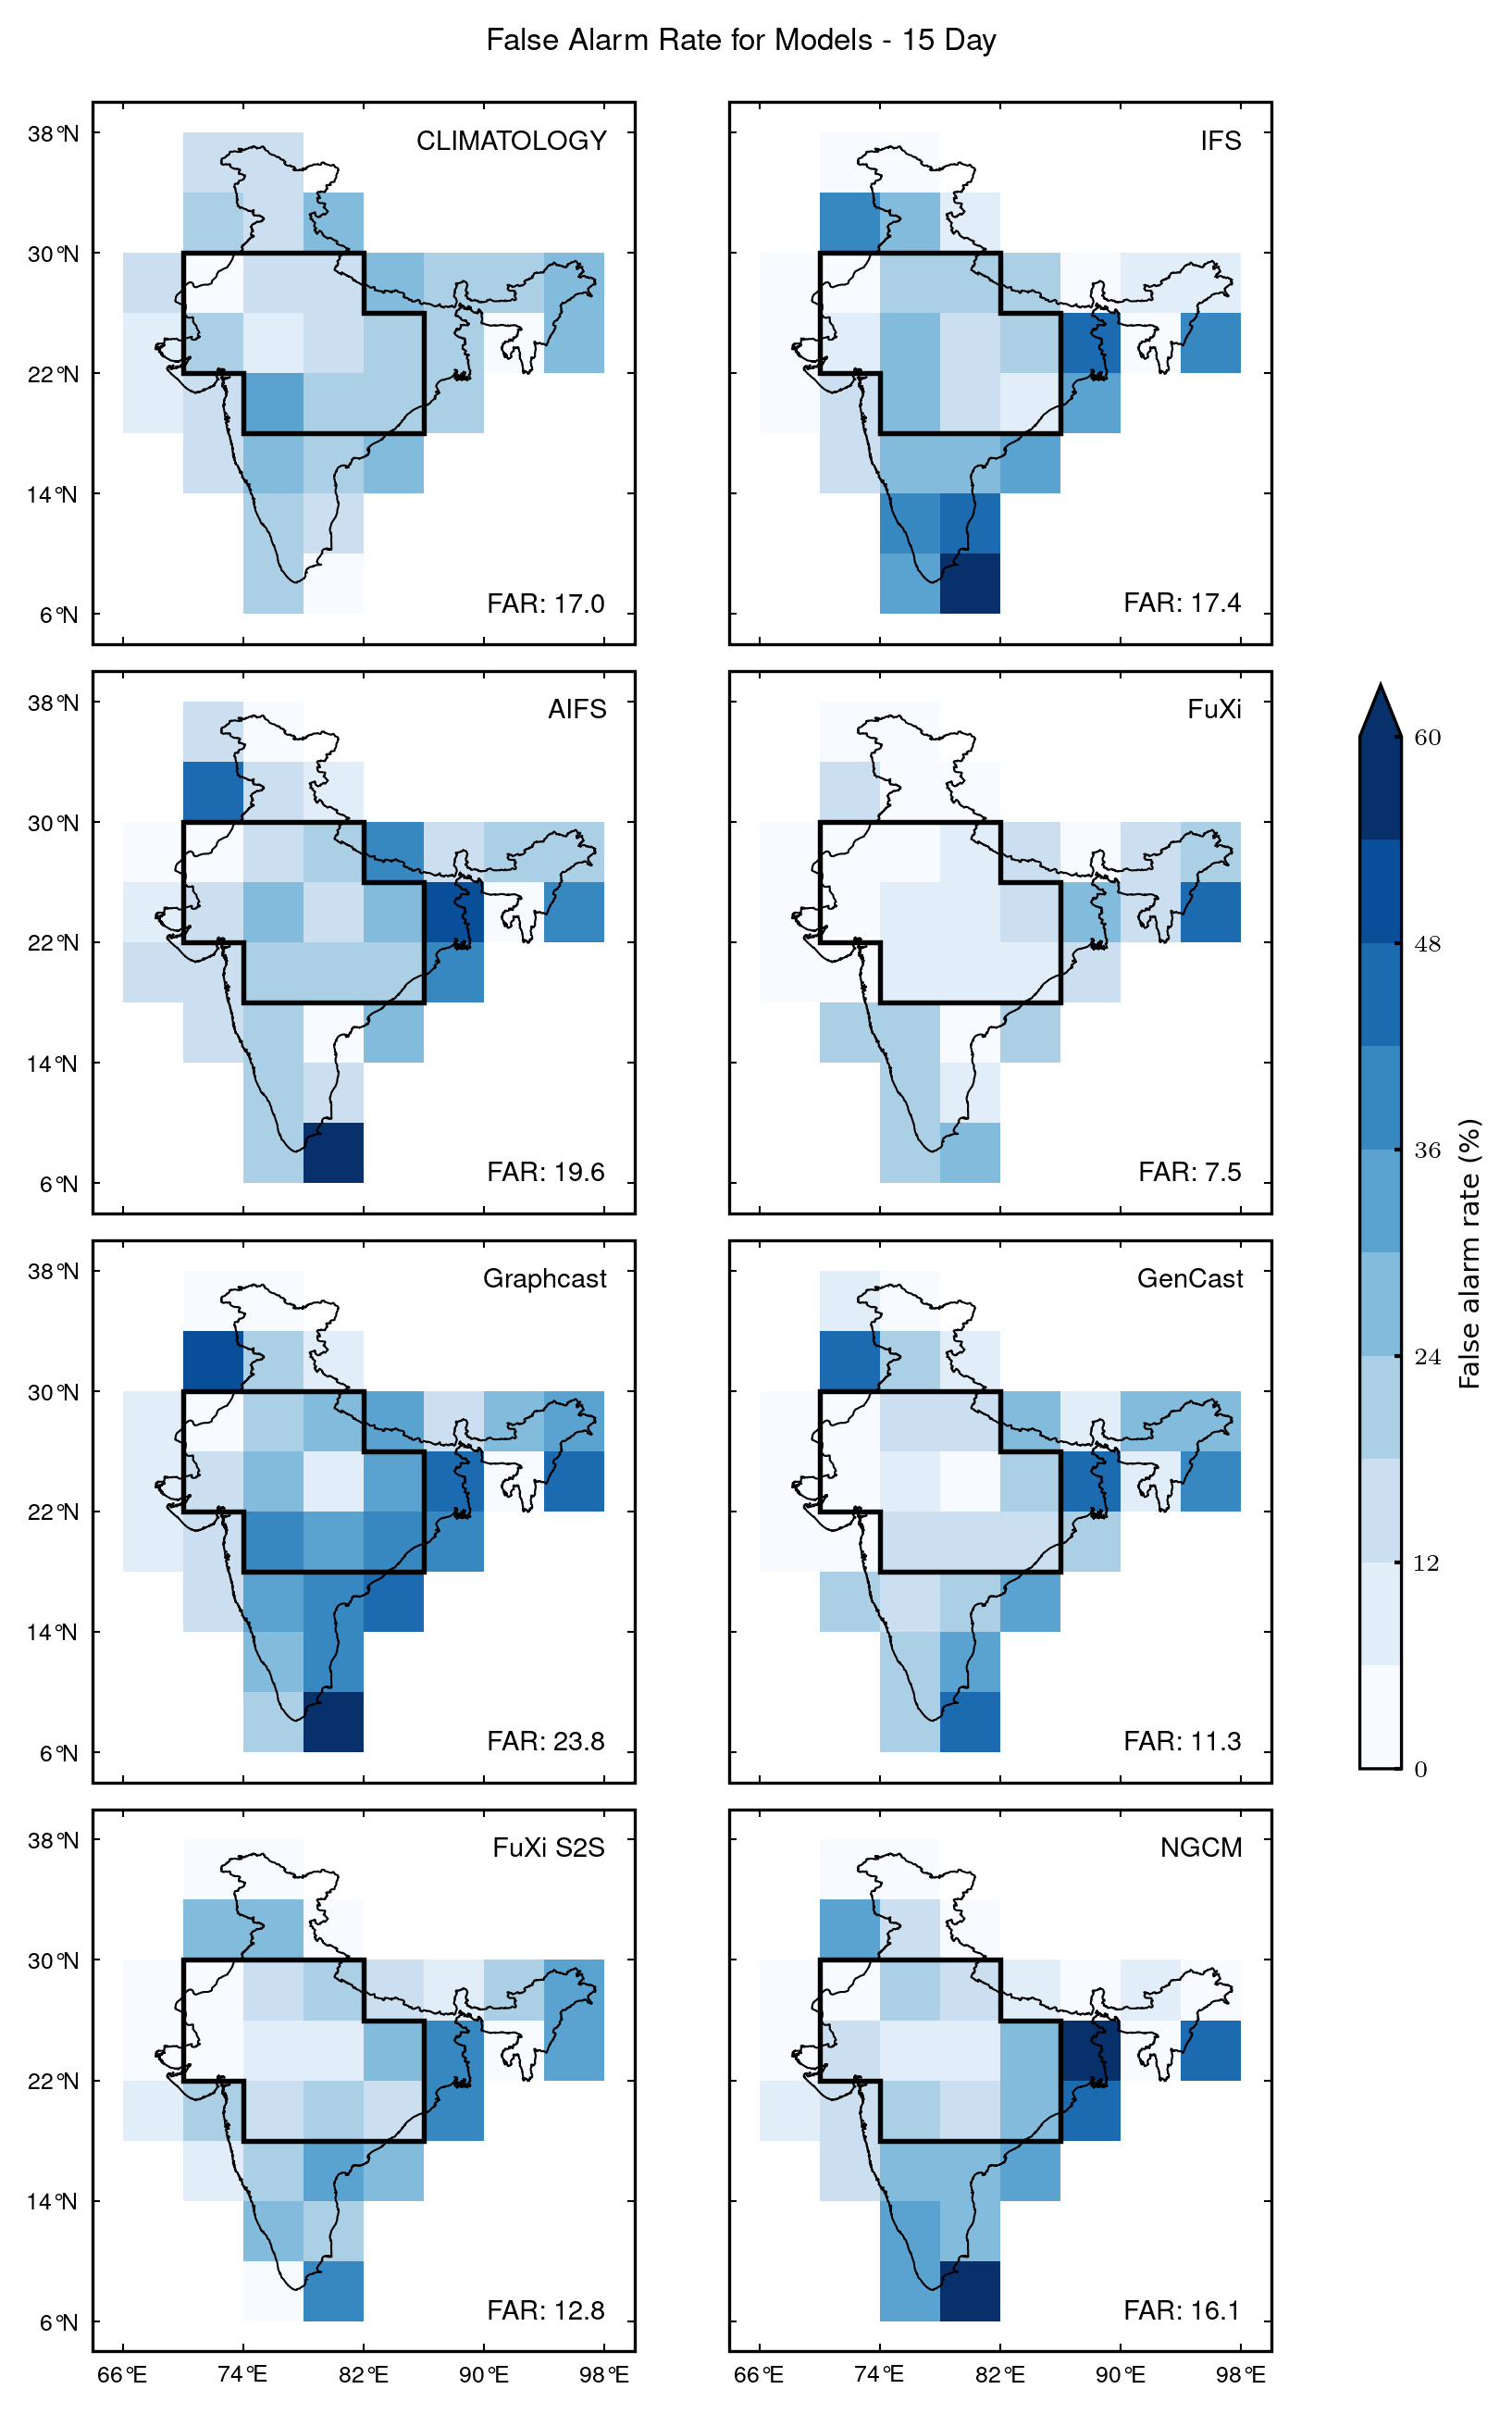

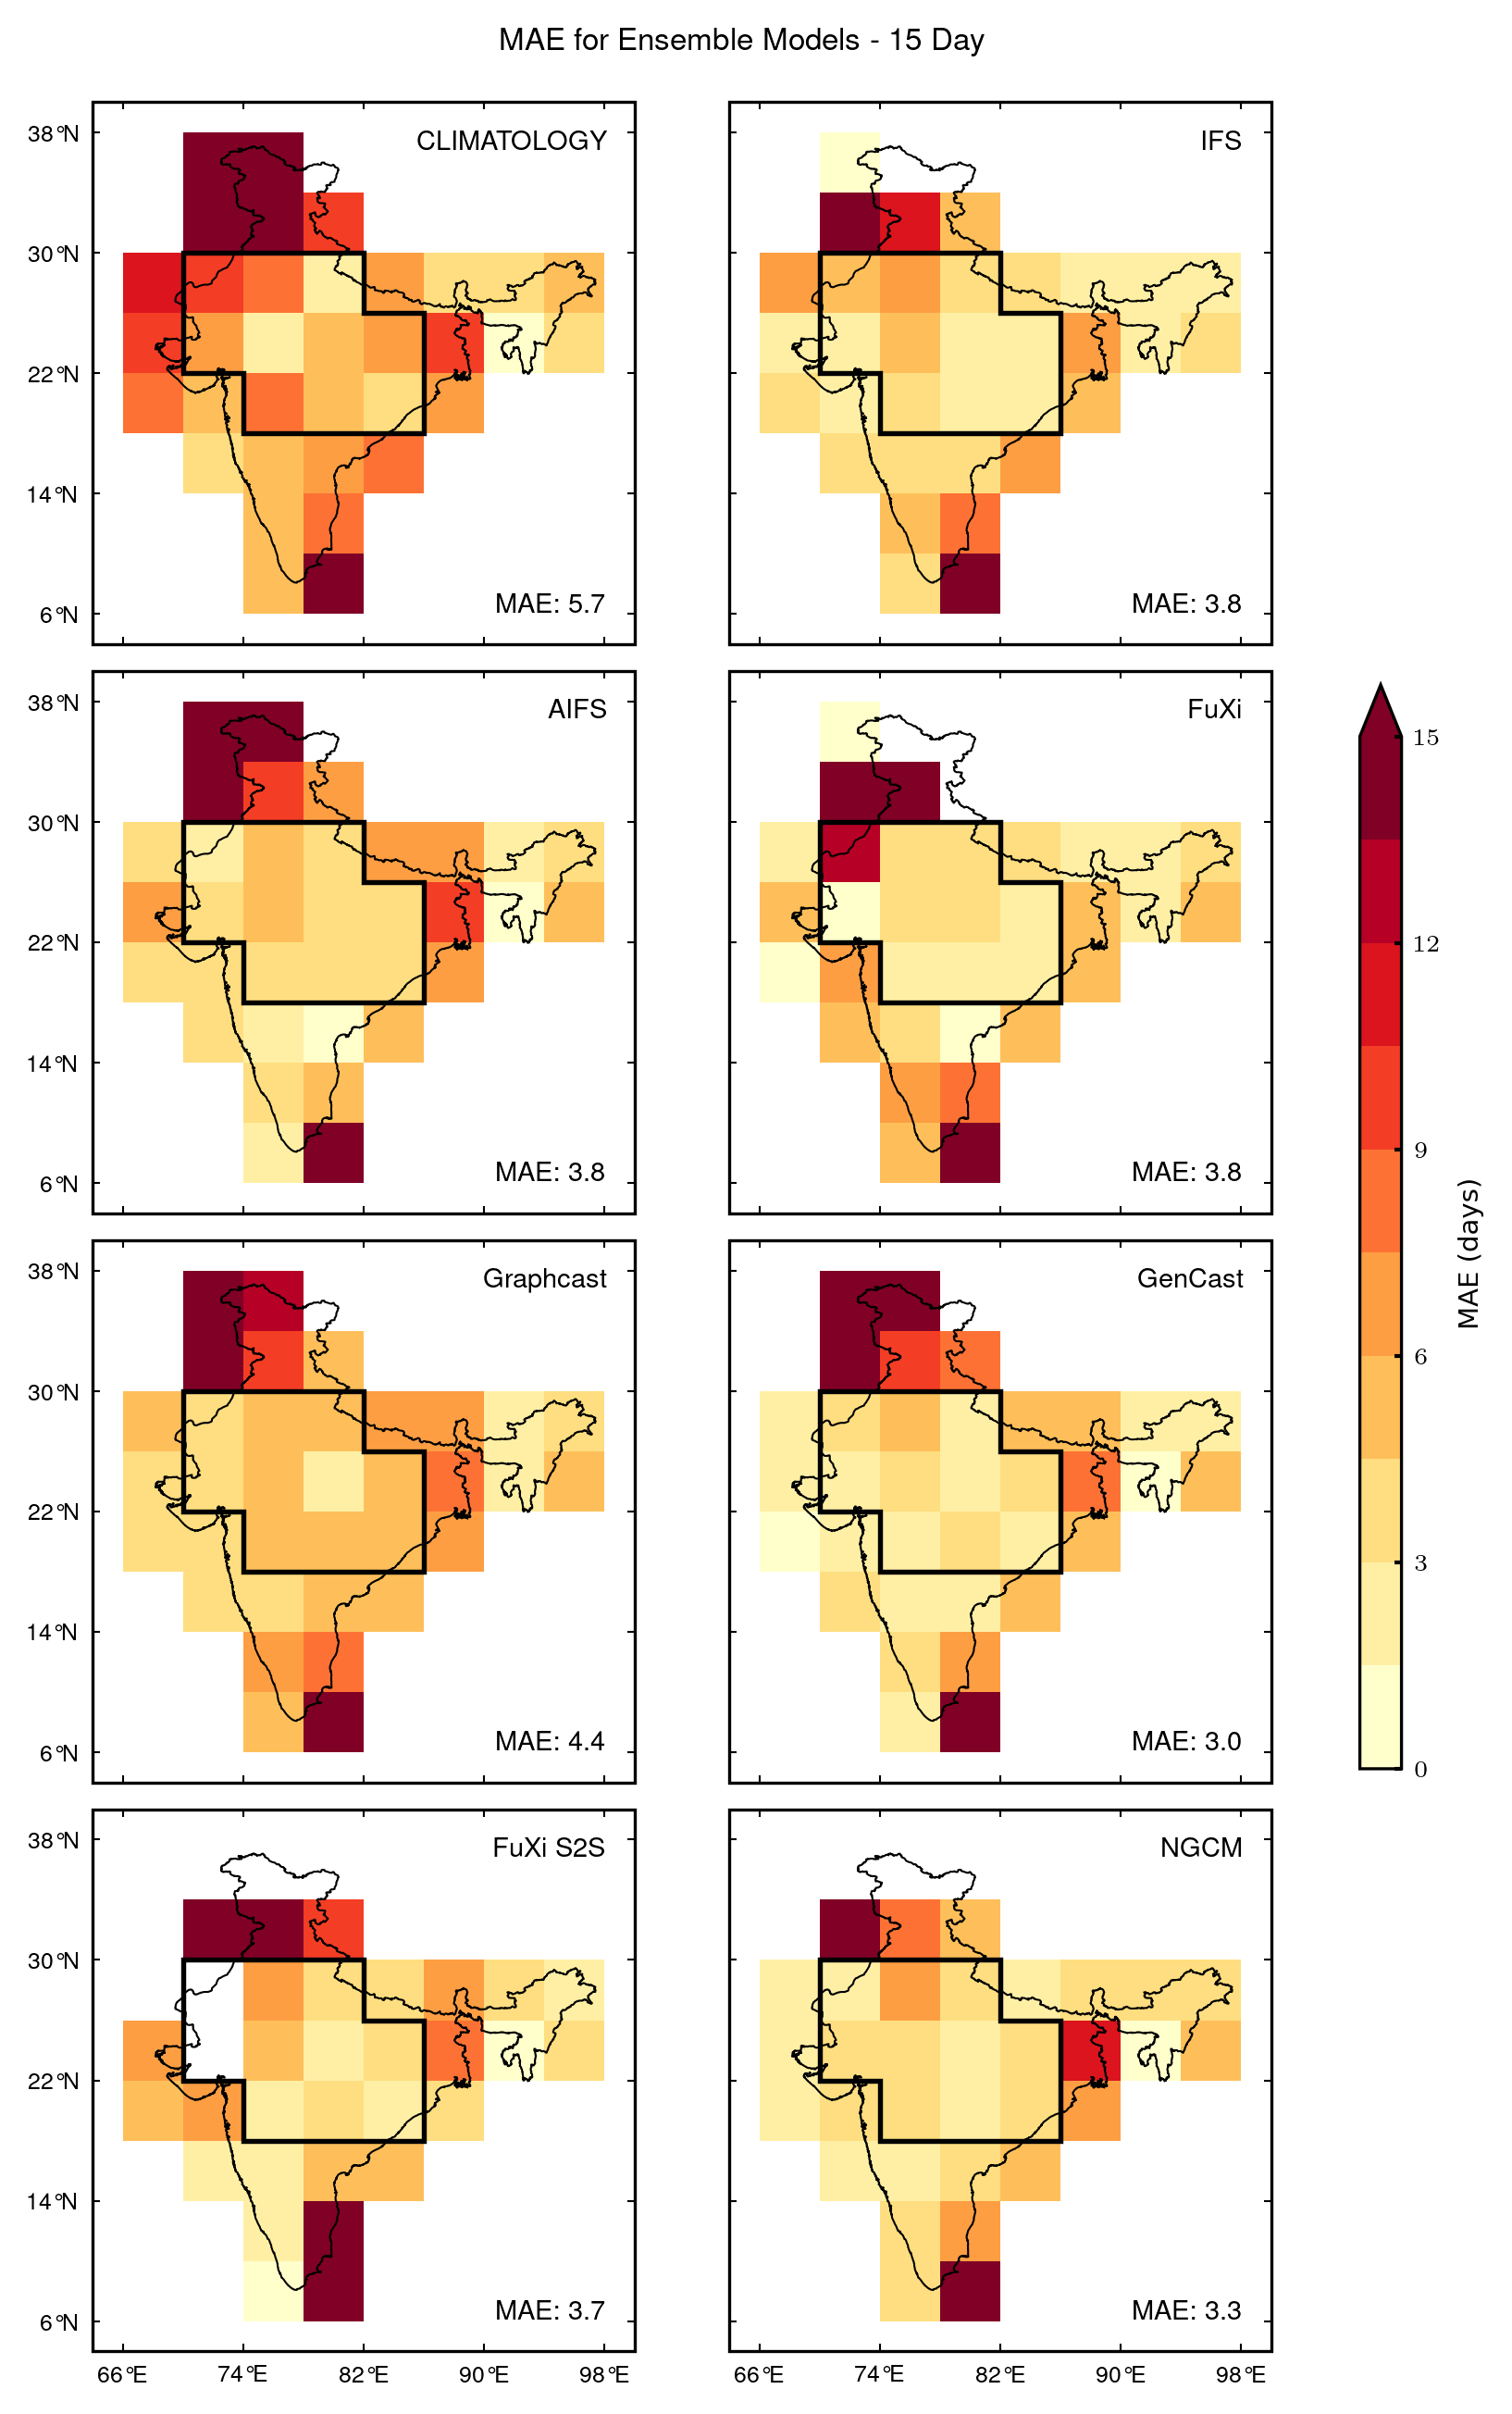

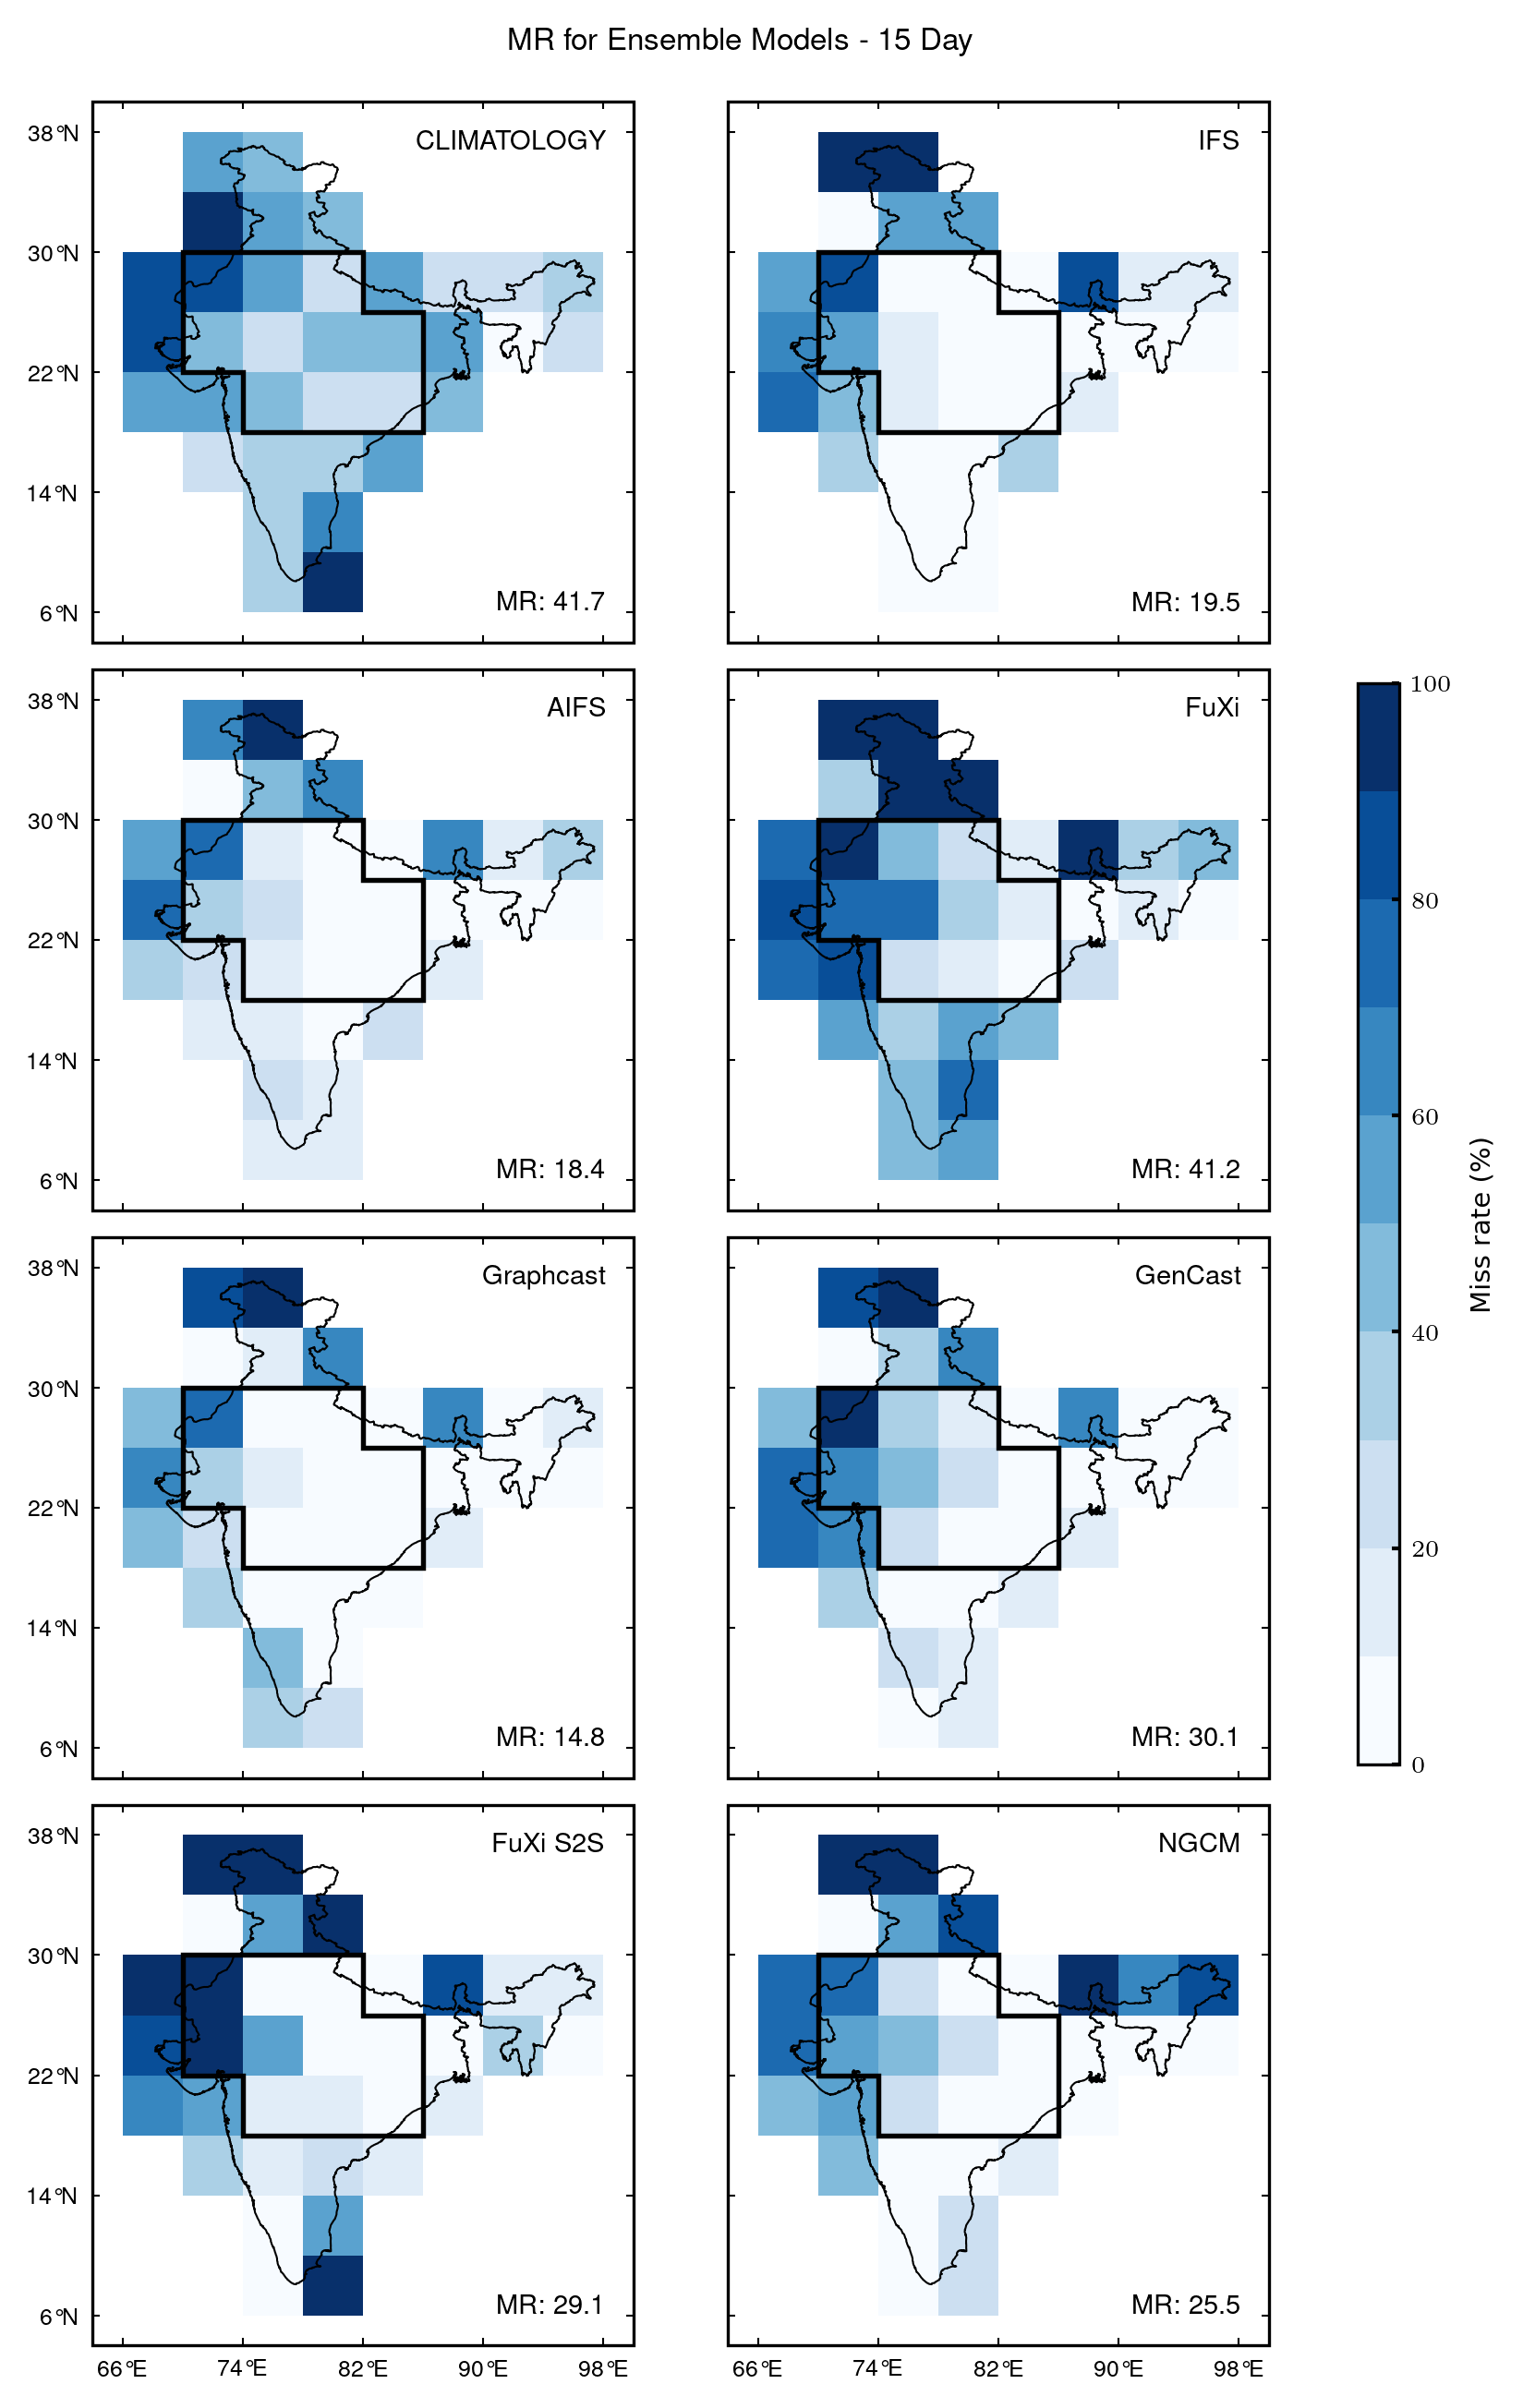

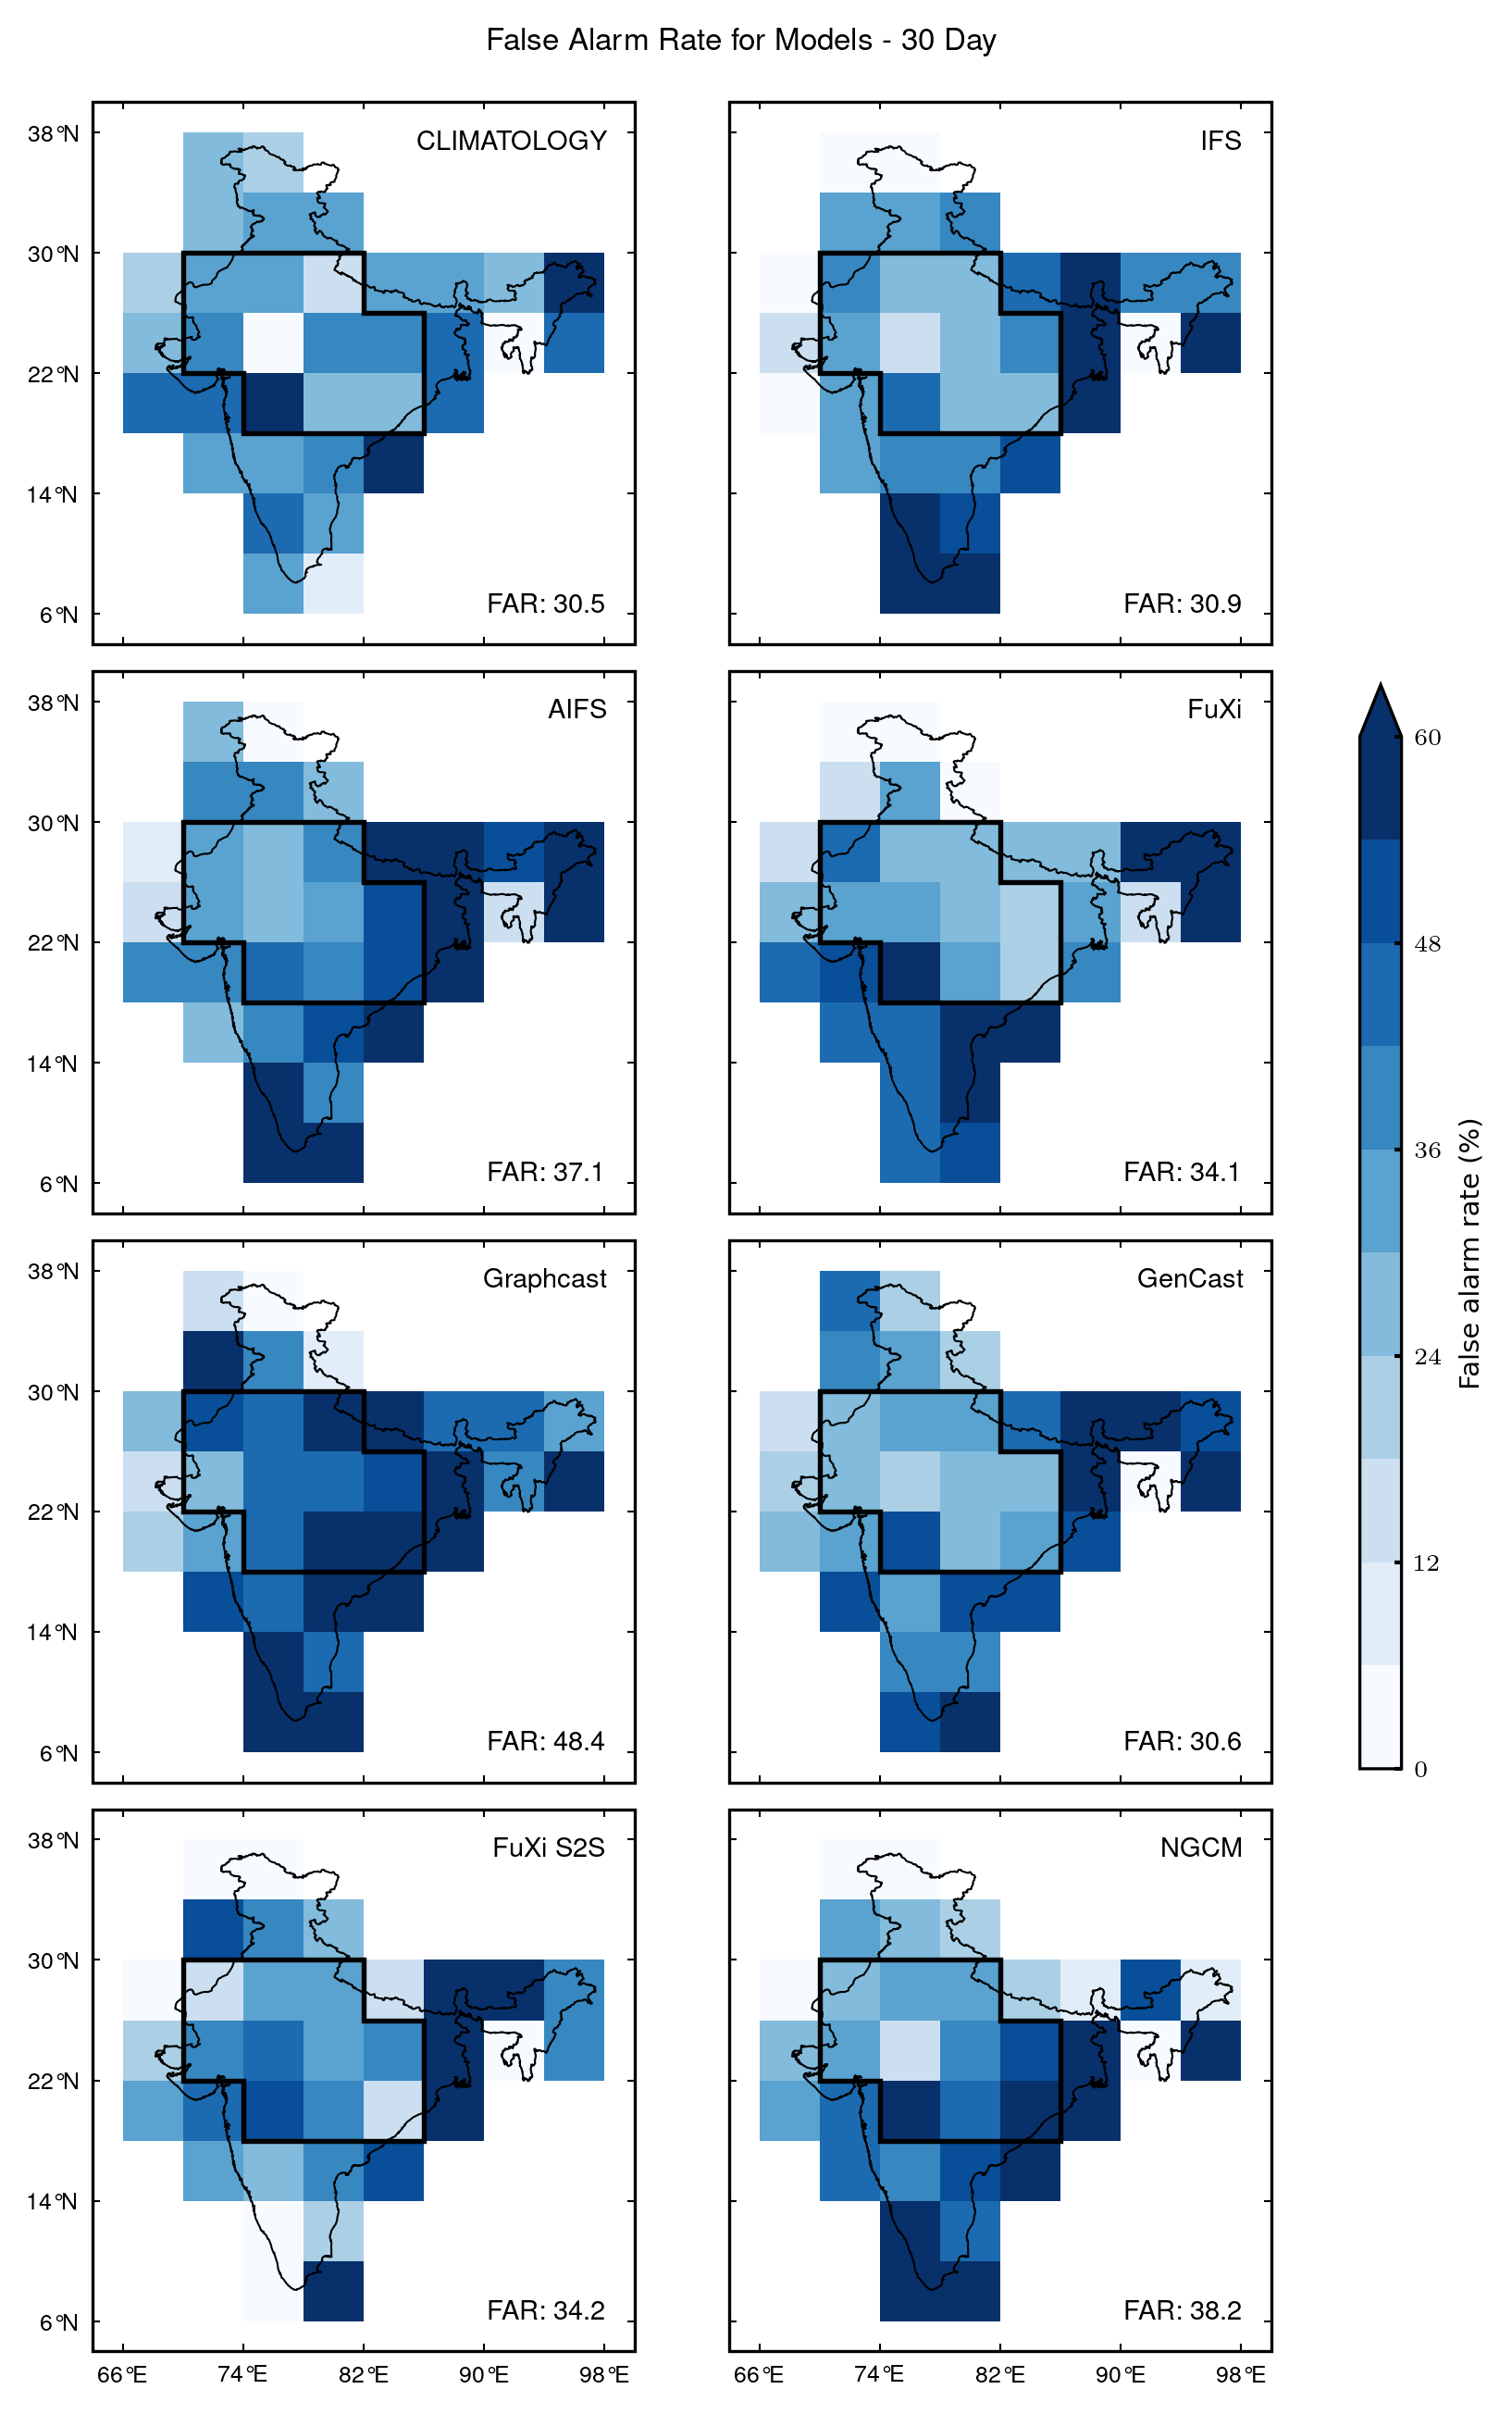

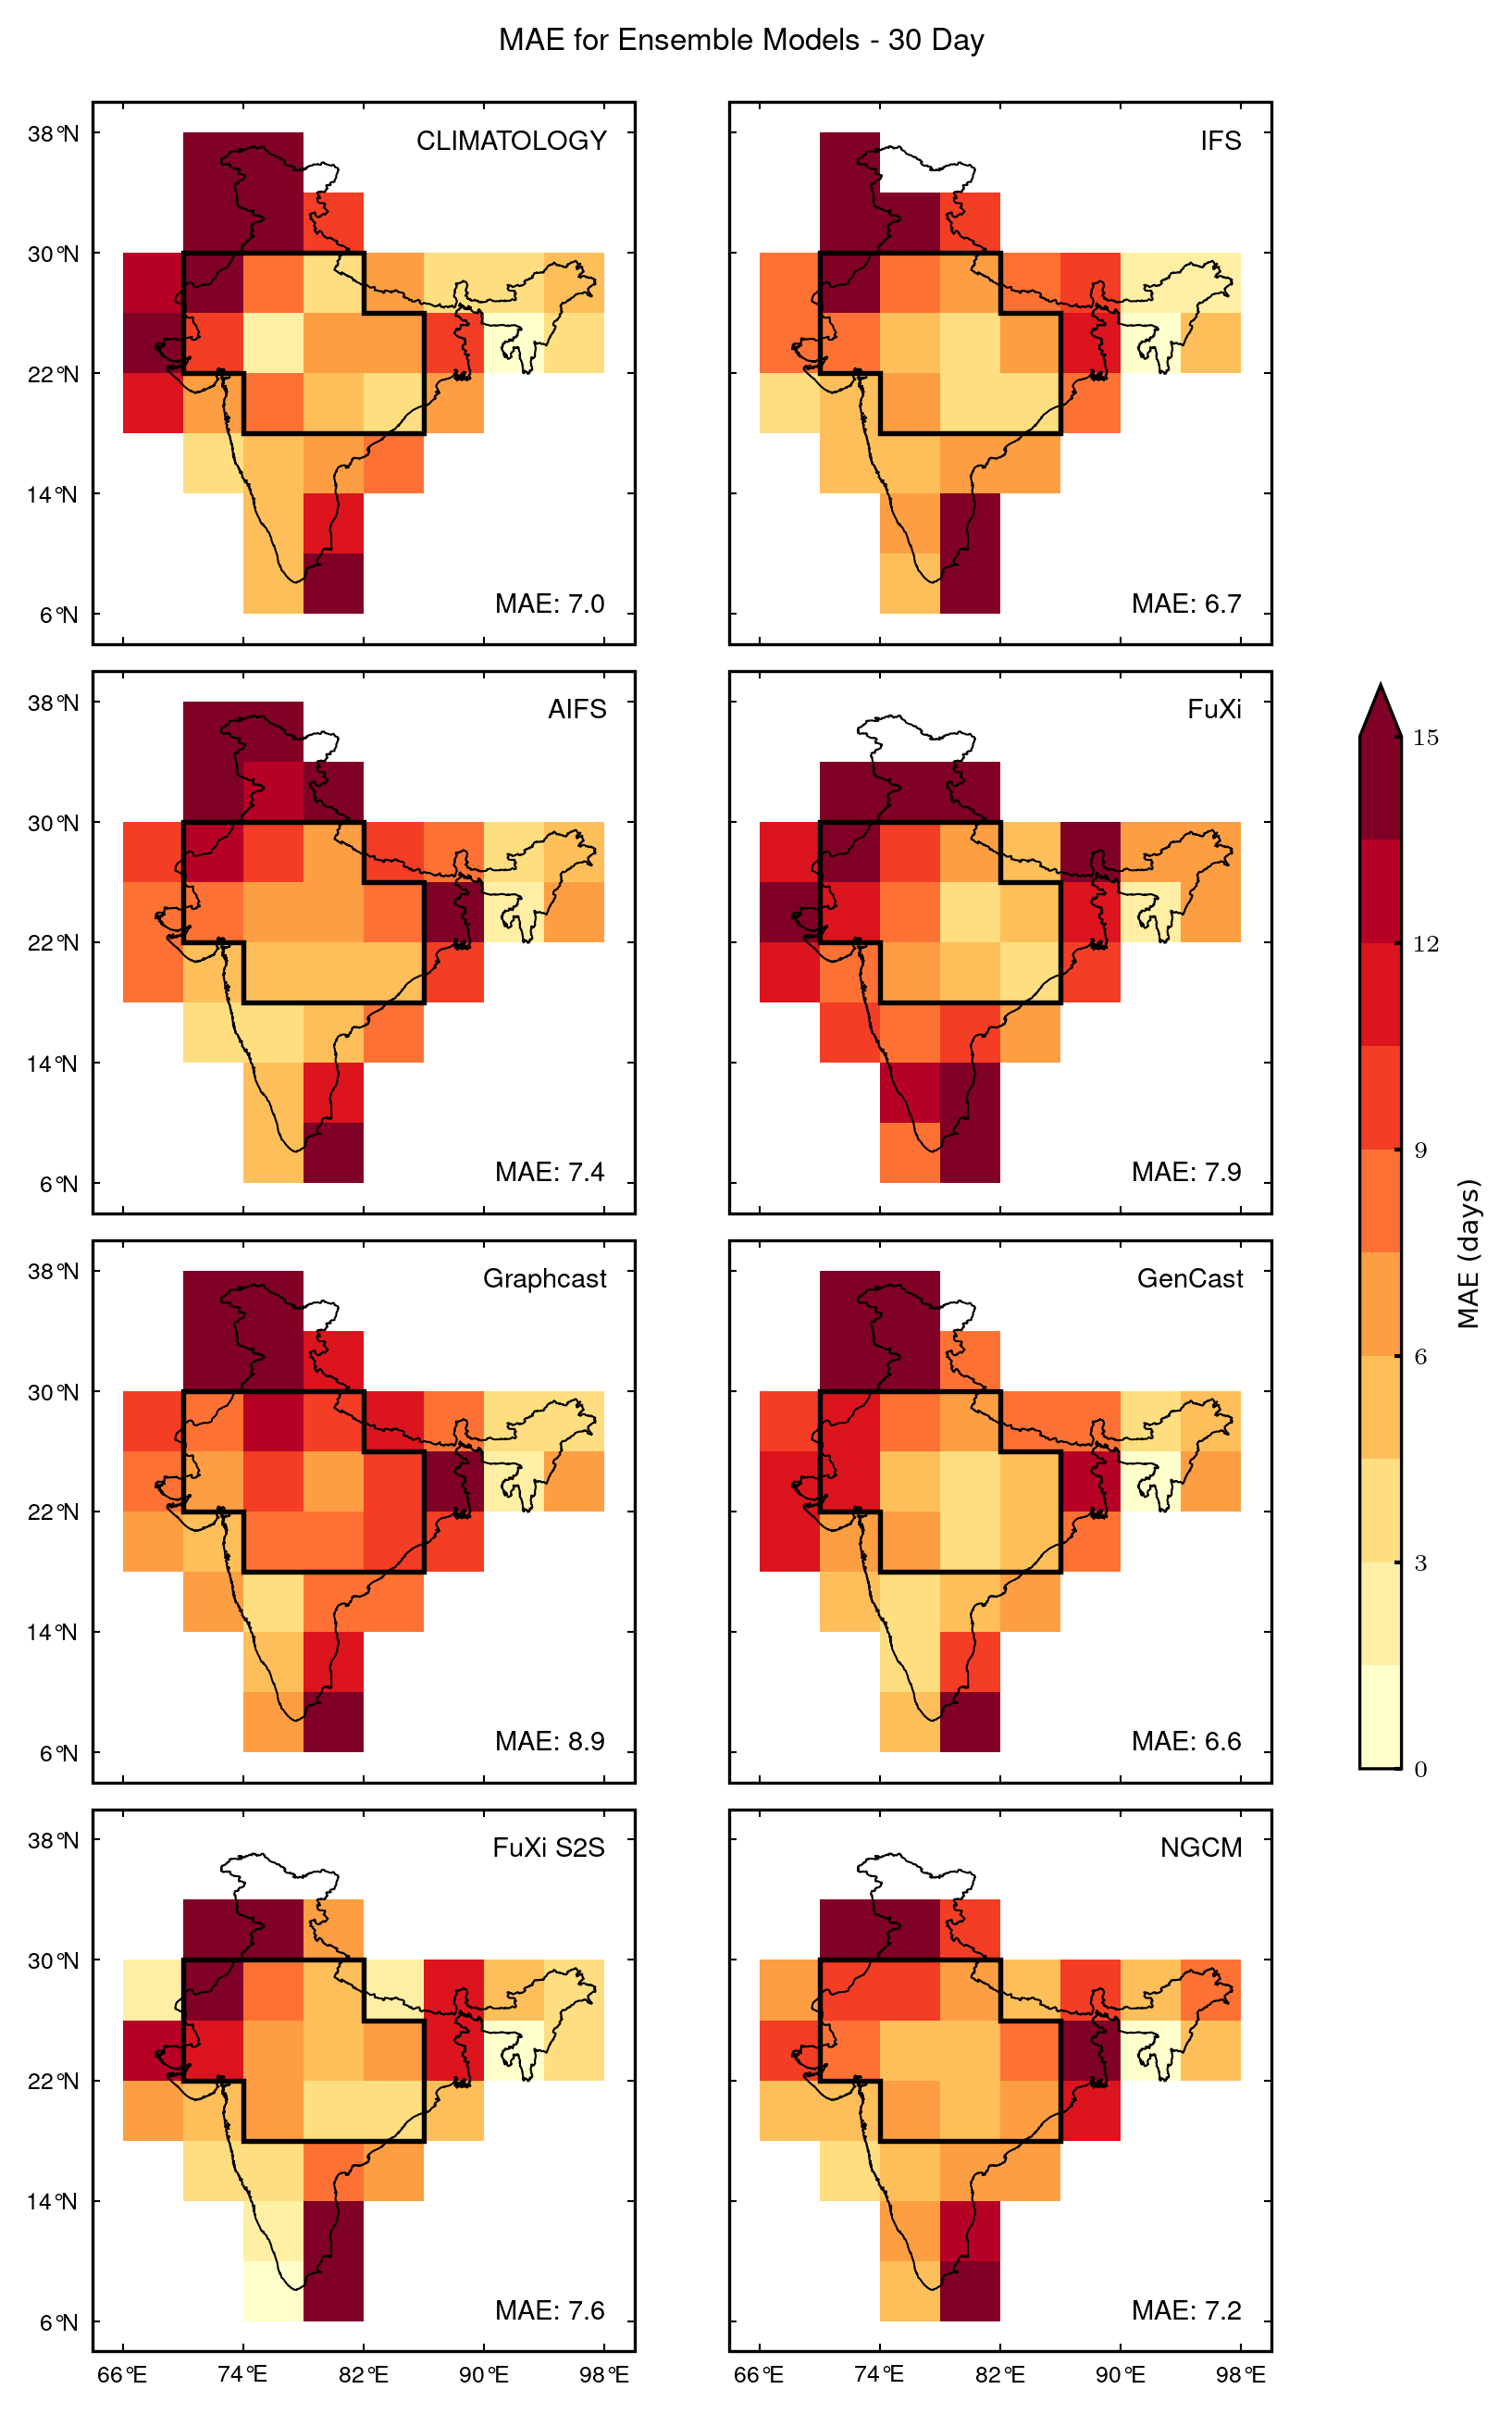

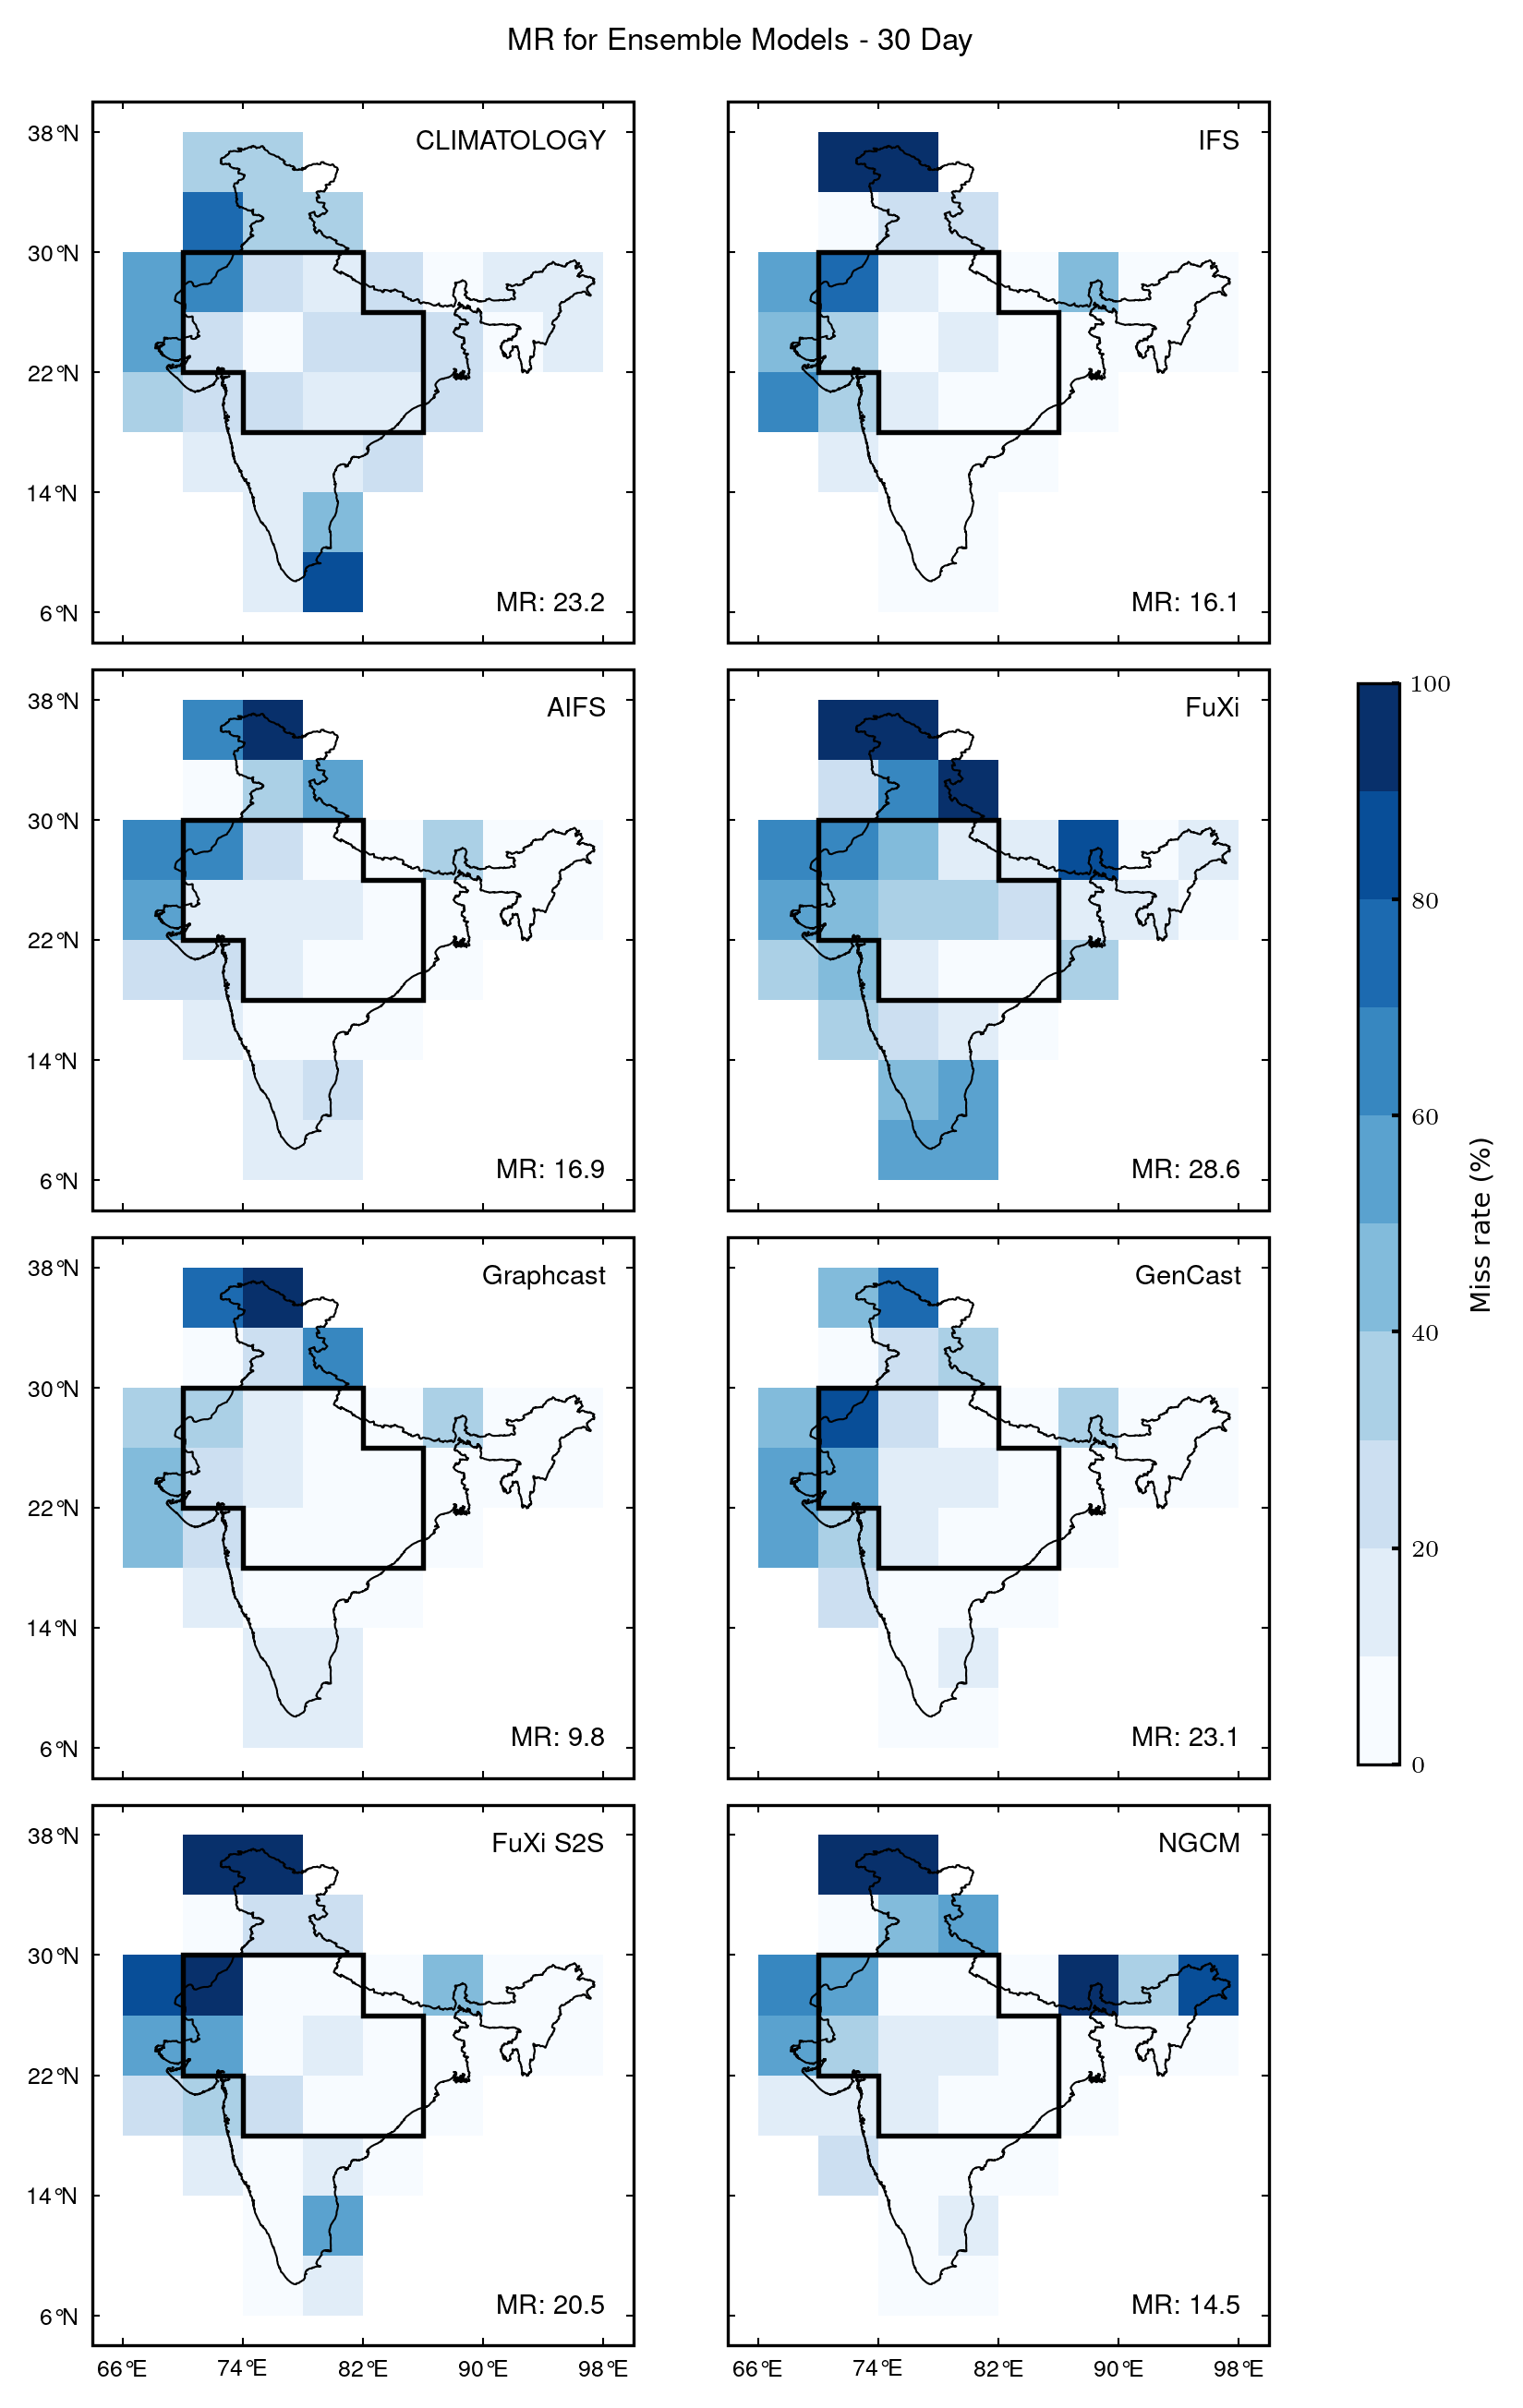

In [55]:
title1 = "False Alarm Rate for Models - 15 Day"
title2 = "MAE for Ensemble Models - 15 Day"
title3 = "MR for Ensemble Models - 15 Day"
title4 = "False Alarm Rate for Models - 30 Day"
title5 = "MAE for Ensemble Models - 30 Day"
title6 = "MR for Ensemble Models - 30 Day"


fig1 = create_spatial_metric_figure_xr(
    plot_data=prob_plot_data_15,
    metric="false_alarm_rate",
    figure_title=title1,
    cmap="Blues",
    vmin=0,
    vmax=60,
    n_colors=10
)
fig2 = create_spatial_metric_figure_xr(
    plot_data=prob_plot_data_15,
    metric="mean_mae",
    figure_title=title2,
    cmap="YlOrRd",
    vmin=0,
    vmax=15,
    n_colors=10
)

fig3 = create_spatial_metric_figure_xr(
    plot_data=prob_plot_data_15,
    metric="miss_rate",
    figure_title=title3,
    cmap="Blues",
    vmin=0,
    vmax=100,
    n_colors=10
)

fig4 = create_spatial_metric_figure_xr(
    plot_data=prob_plot_data_30,
    metric="false_alarm_rate",
    figure_title=title4,
    cmap="Blues",
    vmin=0,
    vmax=60,
    n_colors=10
)
fig5 = create_spatial_metric_figure_xr(
    plot_data=prob_plot_data_30,
    metric="mean_mae",
    figure_title=title5,
    cmap="YlOrRd",
    vmin=0,
    vmax=15,
    n_colors=10
)

fig6 = create_spatial_metric_figure_xr(
    plot_data=prob_plot_data_30,
    metric="miss_rate",
    figure_title=title6,
    cmap="Blues",
    vmin=0,
    vmax=100,
    n_colors=10
)


<xarray.DataArray 'brier_score' (lat: 8, lon: 8)> Size: 512B
array([[       nan,        nan, 0.0752702 , 0.10416558,        nan,
               nan,        nan,        nan],
       [       nan,        nan, 0.06899408, 0.10818336,        nan,
               nan,        nan,        nan],
       [       nan, 0.10604712, 0.05125833, 0.08887287, 0.09252623,
               nan,        nan,        nan],
       [0.13986379, 0.09625008, 0.08960437, 0.08871903, 0.08680228,
        0.13901085,        nan,        nan],
       [0.08803288, 0.07531797, 0.06273092, 0.07128217, 0.0857013 ,
        0.1024305 , 0.09401202, 0.15048242],
       [0.05795936, 0.09430881, 0.05640964, 0.07903175, 0.08660131,
        0.1568818 , 0.08197721, 0.10031645],
       [       nan, 0.13747492, 0.10068418, 0.11391564,        nan,
               nan,        nan,        nan],
       [       nan, 0.11285362, 0.11360191, 0.21428571,        nan,
               nan,        nan,        nan]])
Coordinates:
  * lat      (lat) fl

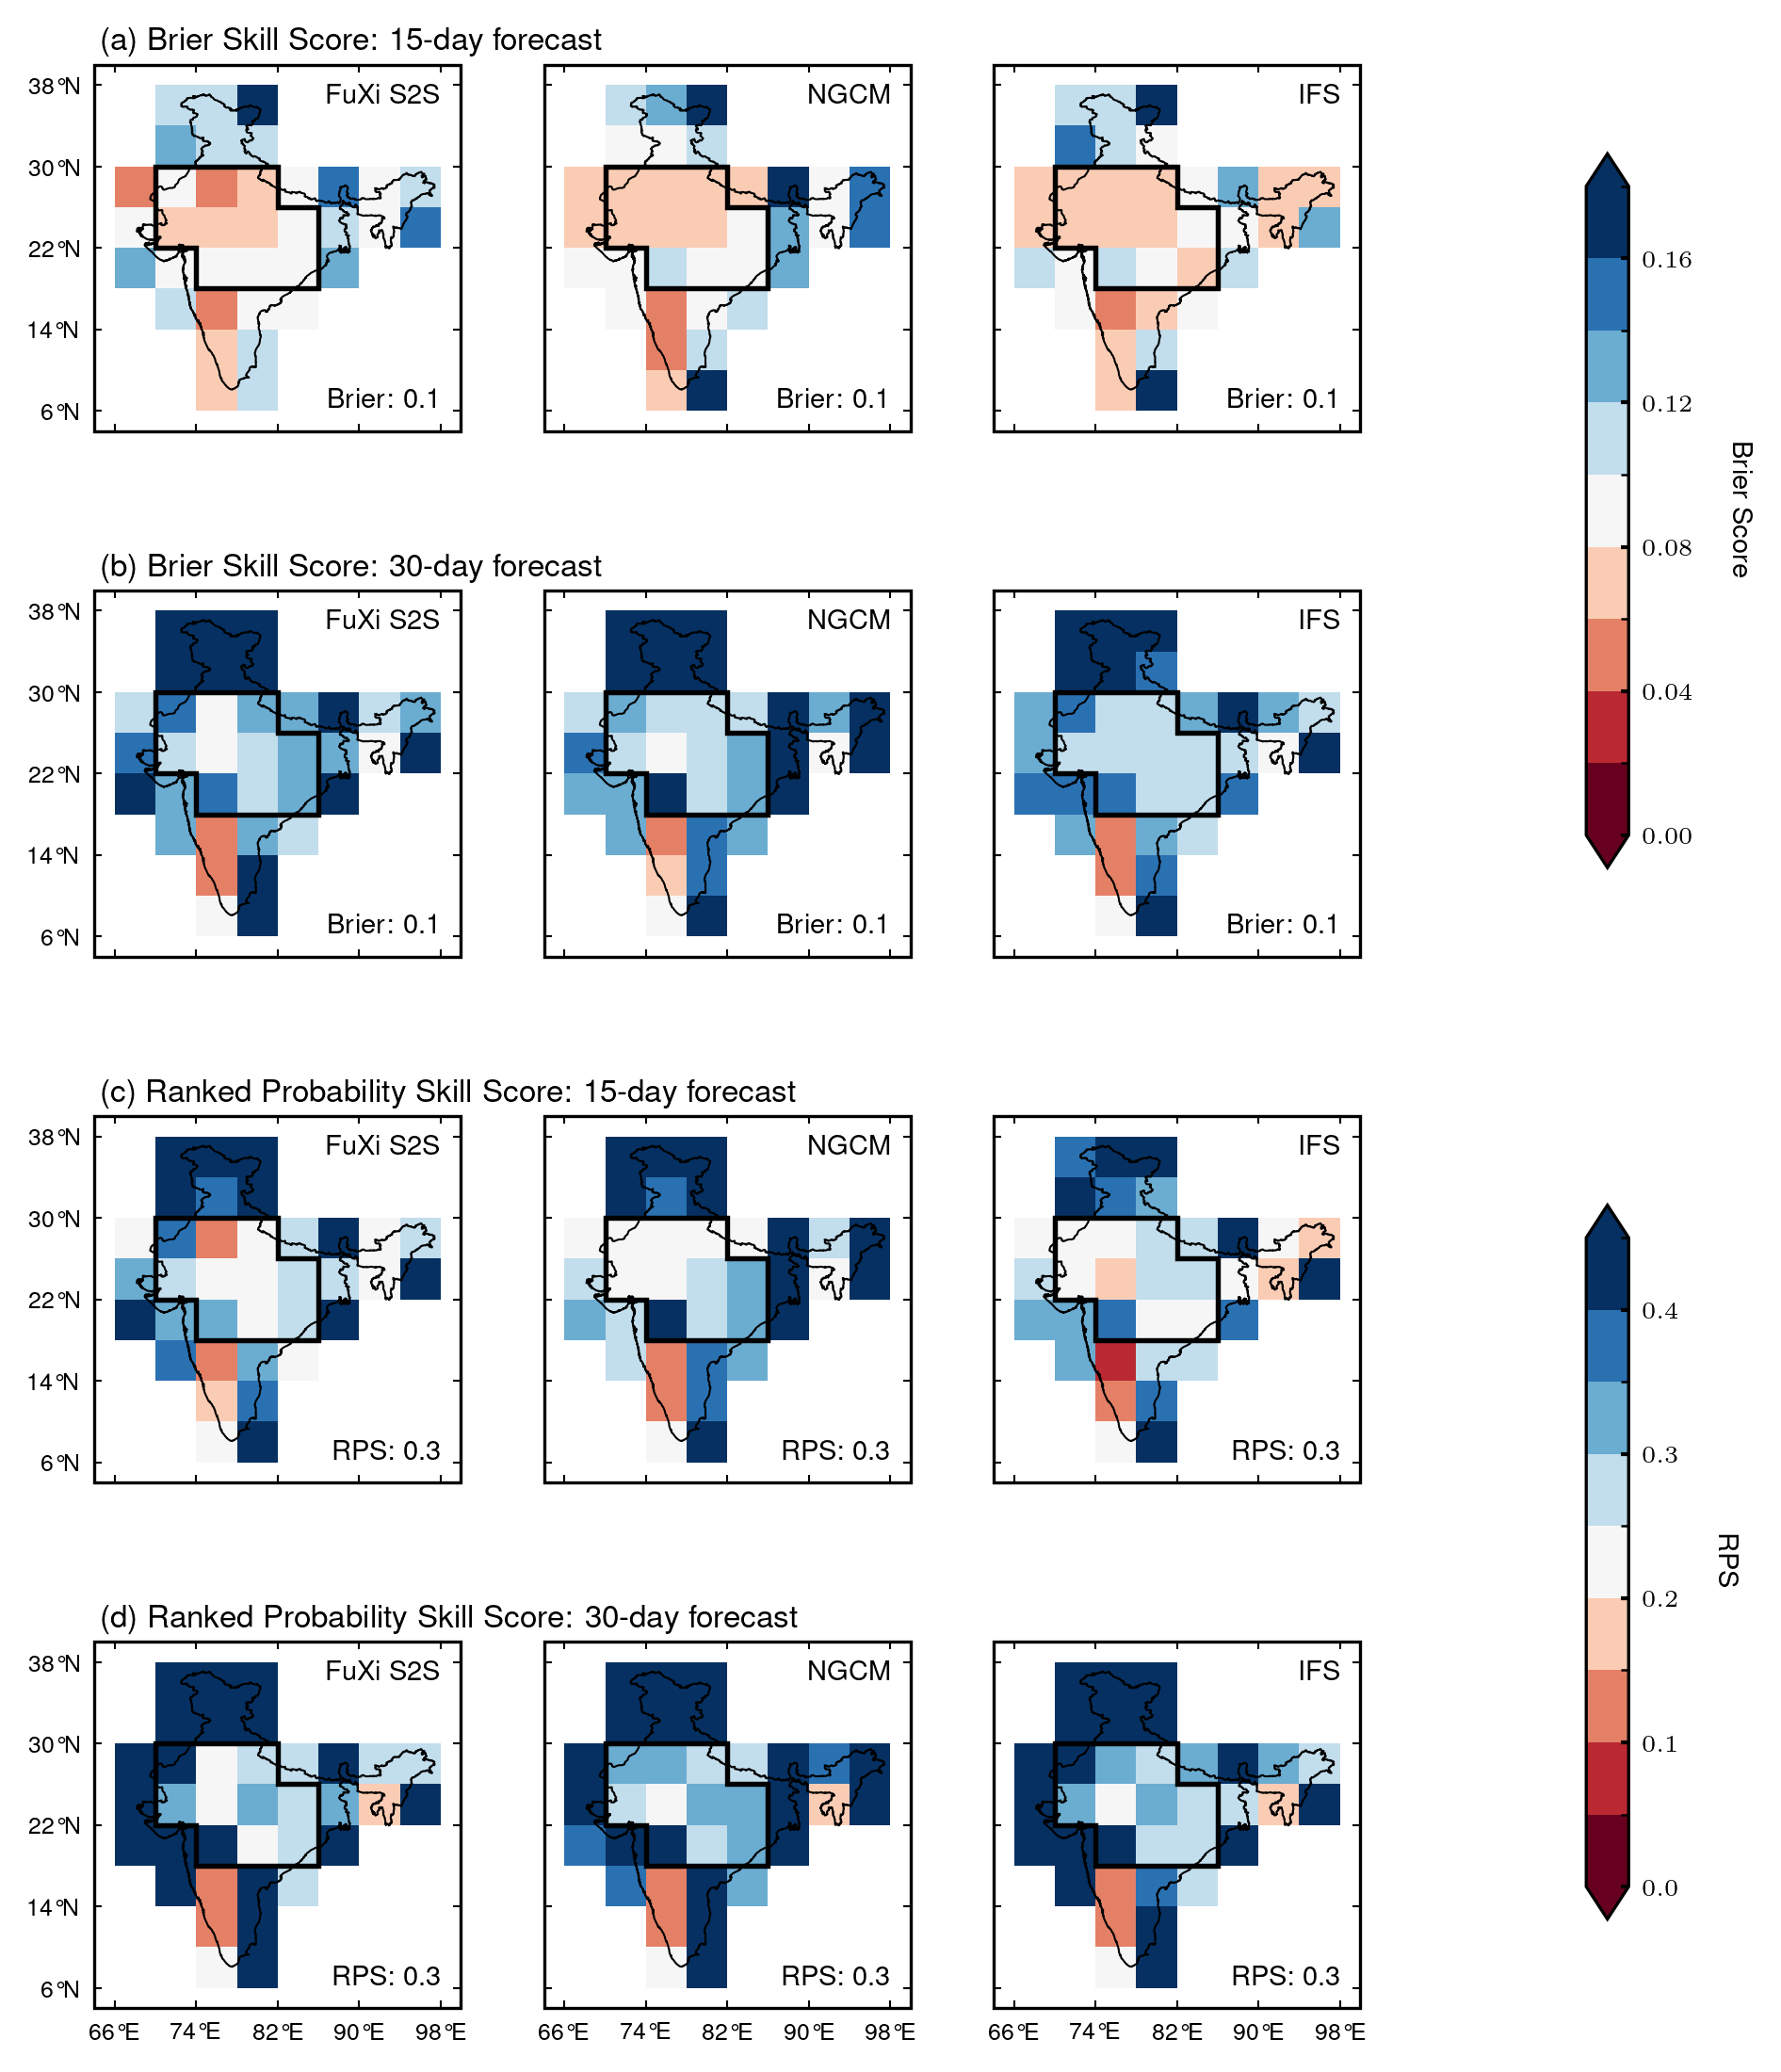

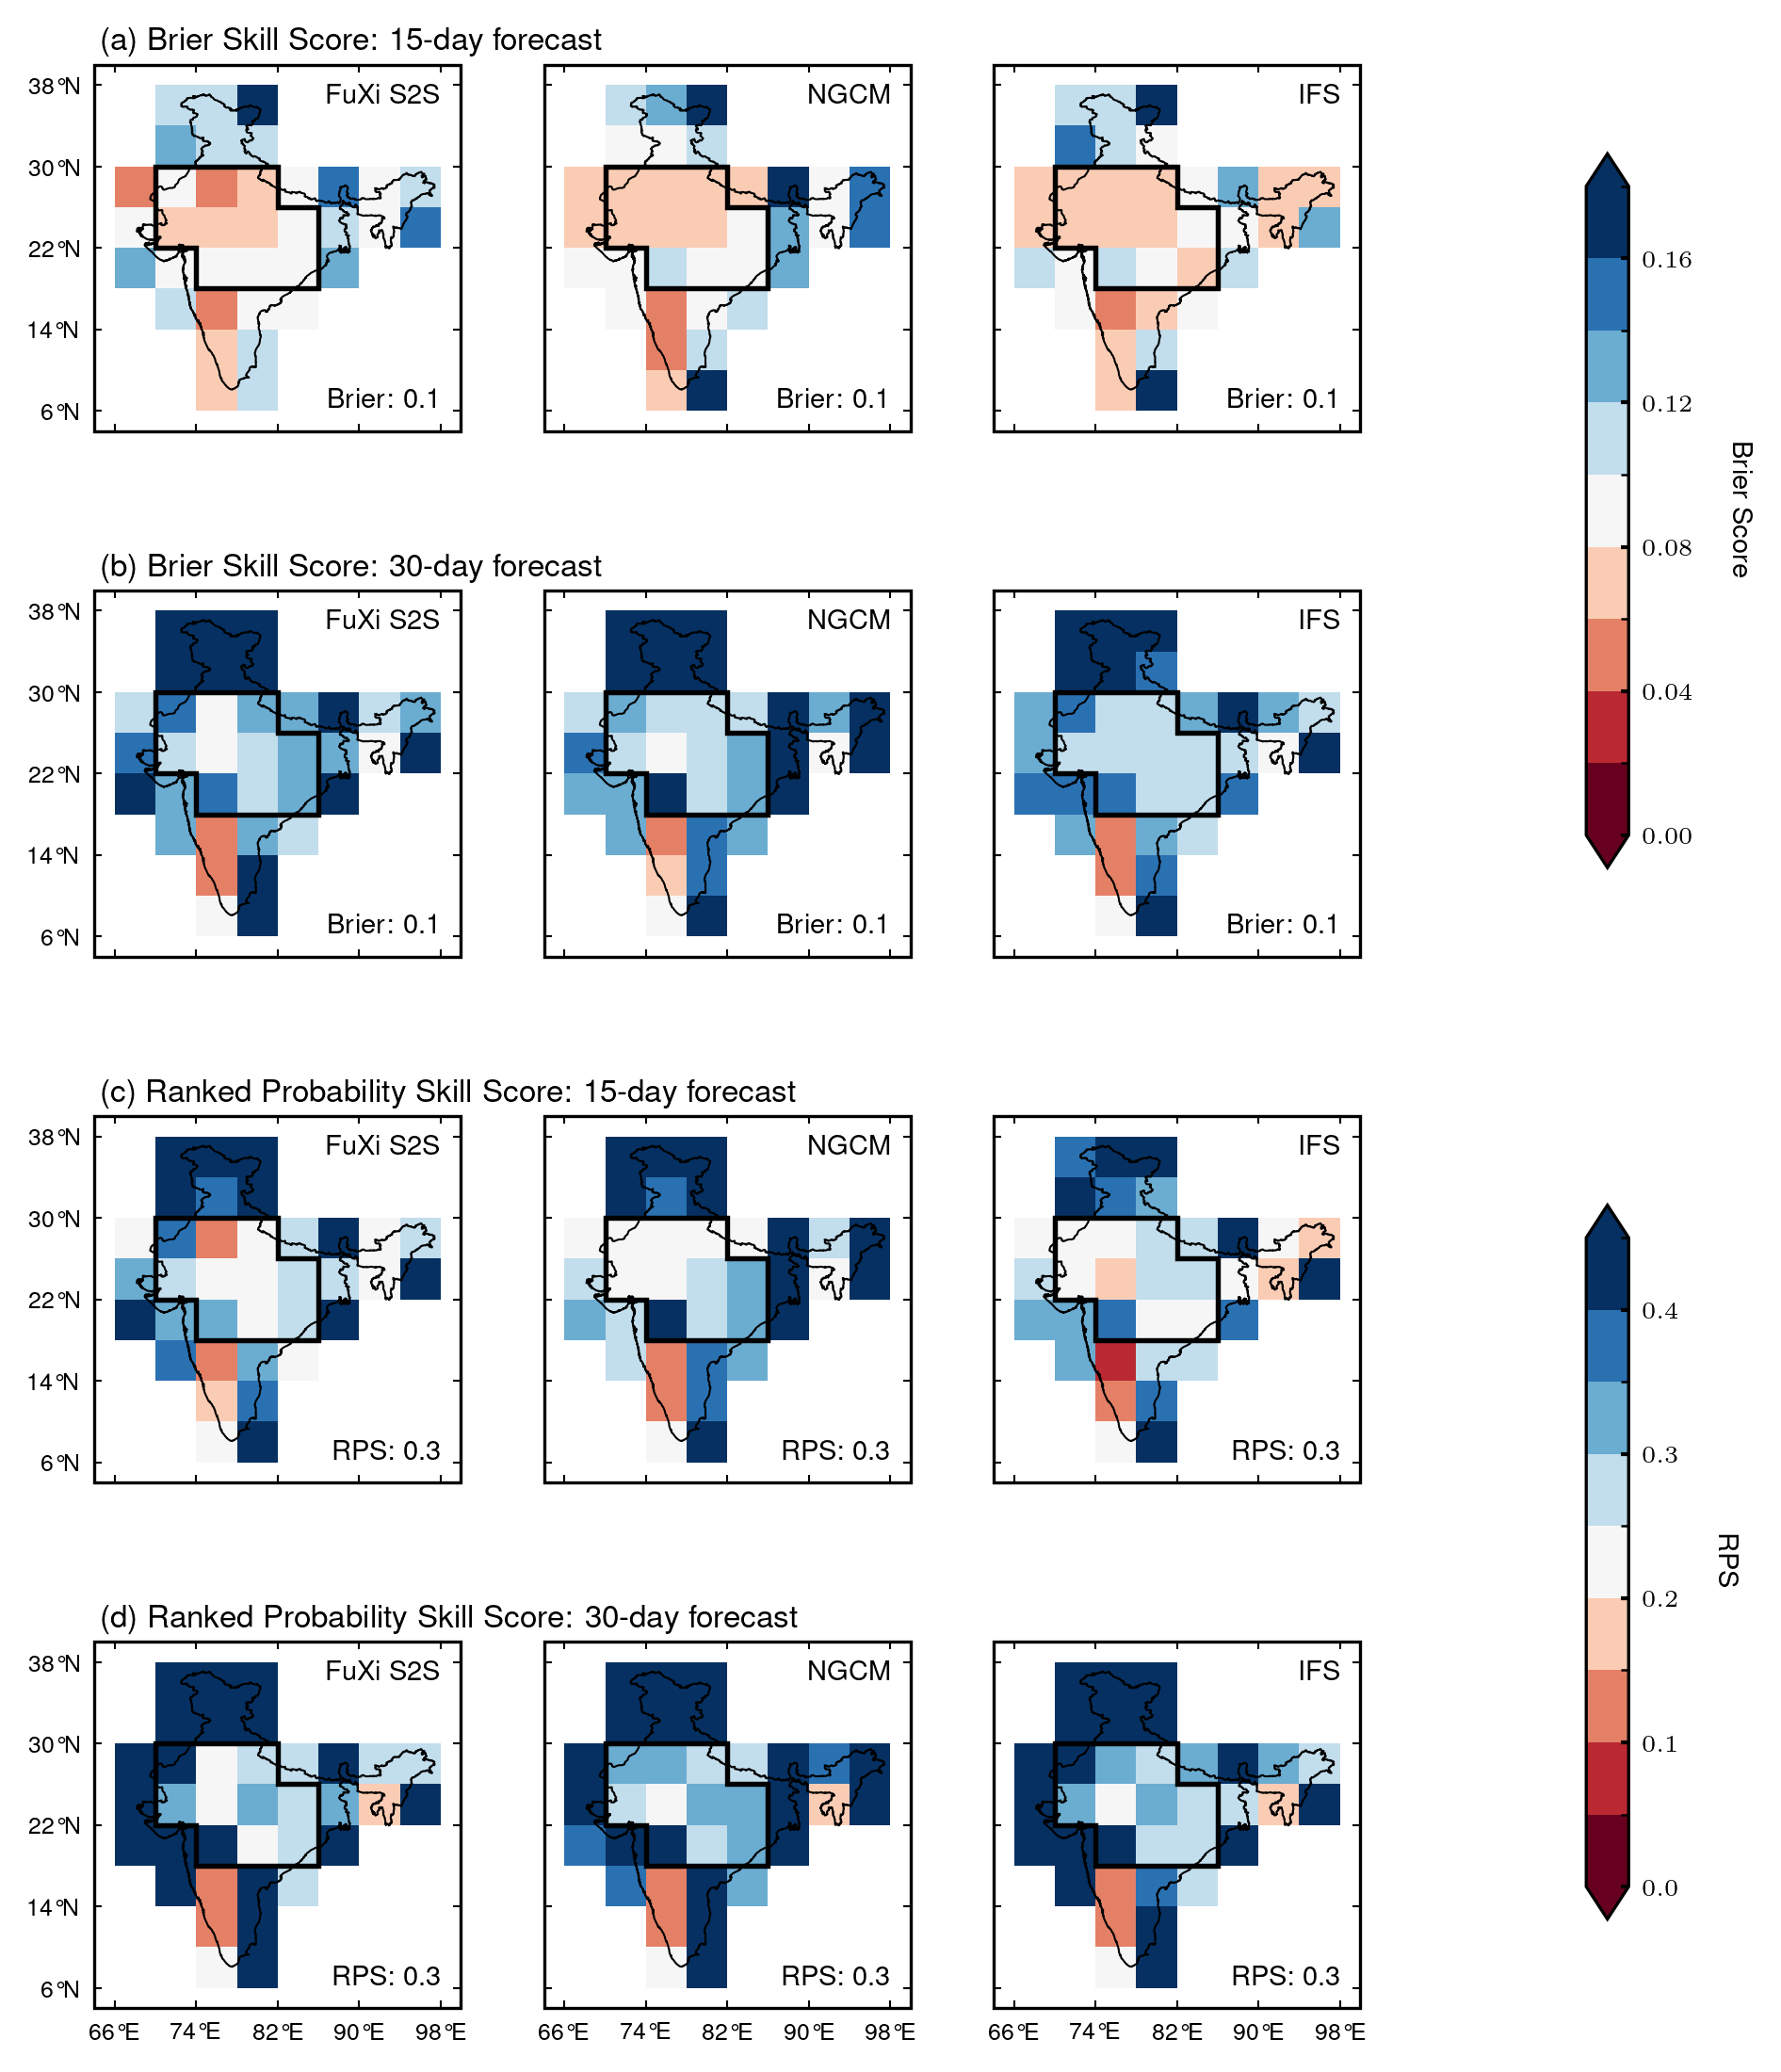

In [76]:
create_brier_rps_maps_figure_from_datasets(brier_rps_graph_data_list)